In [8]:
# ==========================================
# STEP 0: DATASET DISCOVERY & PRE-FLIGHT CHECK
# ==========================================

import os
from google.colab import userdata
from huggingface_hub import HfApi, login
import duckdb
import pandas as pd

# --------------------------------------------------
# 1. Retrieve & Validate HF Token
# --------------------------------------------------

try:
    hf_token = userdata.get("HF_TOKEN")

    if not hf_token:
        raise RuntimeError("HF_TOKEN was not found in Colab Secrets.")

    login(token=hf_token, add_to_git_credential=False)

    print("✓ Hugging Face authentication successful.")

except Exception as e:
    raise RuntimeError(
        f"❌ Authentication error: {e}"
    )


# --------------------------------------------------
# 2. Discover Dataset Repository
# --------------------------------------------------

api = HfApi(token=hf_token)

repo_id = "FlyRank/ml-internship-dataset"

try:
    files = api.list_repo_files(
        repo_id=repo_id,
        repo_type="dataset"
    )

    print(f"\n✓ Found dataset repo: {repo_id}")
    print("\nFiles found in repo:")

    parquet_files = []

    for f in files:
        print(f"  - {f}")

        if f.lower().endswith(".parquet"):
            parquet_files.append(f)

    print(f"\n✓ Parquet files found: {len(parquet_files)}")

except Exception as e:
    print(f"\n❌ Could not access dataset repository.")
    print(f"Repository: {repo_id}")
    print(f"Details: {e}")

    parquet_files = []


# --------------------------------------------------
# 3. Stop if Repository / Files Were Not Found
# --------------------------------------------------

if not parquet_files:
    print(
        "\n⚠️ No Parquet files were discovered."
        "\nDo NOT continue with the ML notebook yet."
        "\nThe repository name or dataset access must be verified first."
    )

else:

    # --------------------------------------------------
    # 4. Schema Discovery via DuckDB
    # --------------------------------------------------

    print("\n🔍 Attempting schema discovery...")

    try:
        con = duckdb.connect()

        for parquet_file in parquet_files:

            parquet_url = (
                f"hf://datasets/{repo_id}/{parquet_file}"
            )

            print(f"\nInspecting: {parquet_file}")

            schema_df = con.execute(
                f"DESCRIBE SELECT * FROM '{parquet_url}'"
            ).df()

            print("\n✓ Actual Schema:")
            print(
                schema_df[
                    ["column_name", "column_type"]
                ].to_string(index=False)
            )

    except Exception as e:
        print("\n❌ DuckDB Schema Inspection Failed.")
        print(f"Details: {e}")

        print(
            "\nThe Hugging Face repository was discovered, "
            "but DuckDB could not inspect the Parquet file."
        )

✓ Hugging Face authentication successful.

❌ Could not access dataset repository.
Repository: FlyRank/ml-internship-dataset
Details: 404 Client Error. (Request ID: Root=1-6aa36a74-7a128ce7078ffb361538f373;88728359-f765-467f-9a94-9d8208f98756)

Repository Not Found for url: https://huggingface.co/api/datasets/FlyRank/ml-internship-dataset/tree/main?recursive=true&expand=false.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication

⚠️ No Parquet files were discovered.
Do NOT continue with the ML notebook yet.
The repository name or dataset access must be verified first.


In [9]:
from huggingface_hub import HfApi
from google.colab import userdata

token = userdata.get("HF_TOKEN")
api = HfApi(token=token)

me = api.whoami()

print("HF username:", me["name"])

HF username: MoamenAbouhaty


In [10]:
from google.colab import userdata
from huggingface_hub import HfApi

token = userdata.get("HF_TOKEN")
api = HfApi(token=token)

print("Searching Hugging Face datasets...\n")

results = list(
    api.list_datasets(
        search="FlyRank",
        limit=50,
        token=token
    )
)

if not results:
    print("❌ No datasets found for search: FlyRank")
else:
    print(f"✓ Found {len(results)} possible datasets:\n")

    for ds in results:
        print(
            f"ID: {ds.id} | "
            f"Private: {ds.private} | "
            f"Gated: {ds.gated}"
        )

Searching Hugging Face datasets...

✓ Found 3 possible datasets:

ID: FlyRank/internship-warehouse | Private: False | Gated: auto
ID: FlyRank/internship-starter | Private: False | Gated: False
ID: FlyRank/internship-lanes | Private: False | Gated: auto


In [6]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN not found in Colab Secrets")

print("✅ HF_TOKEN loaded successfully")

✅ HF_TOKEN loaded successfully


In [11]:
# ==========================================
# STEP 0A: VERIFY FLYRANK WAREHOUSE ACCESS
# ==========================================

from google.colab import userdata
from huggingface_hub import HfApi

token = userdata.get("HF_TOKEN")

if not token:
    raise RuntimeError("HF_TOKEN not found.")

api = HfApi(token=token)

repo_id = "FlyRank/internship-warehouse"

try:
    files = api.list_repo_files(
        repo_id=repo_id,
        repo_type="dataset"
    )

    print(f"✓ Dataset accessible: {repo_id}")
    print("\nFiles:")

    parquet_files = []

    for f in files:
        print(f"  - {f}")

        if f.lower().endswith(".parquet"):
            parquet_files.append(f)

    print(f"\n✓ Parquet files found: {len(parquet_files)}")

except Exception as e:
    print("❌ Dataset access failed.")
    print(f"Details: {e}")

✓ Dataset accessible: FlyRank/internship-warehouse

Files:
  - .gitattributes
  - README.md
  - dim_clients.parquet
  - dim_content.parquet
  - fact_content_daily_performance/month=2025-01/data_0.parquet
  - fact_content_daily_performance/month=2025-02/data_0.parquet
  - fact_content_daily_performance/month=2025-03/data_0.parquet
  - fact_content_daily_performance/month=2025-04/data_0.parquet
  - fact_content_daily_performance/month=2025-05/data_0.parquet
  - fact_content_daily_performance/month=2025-06/data_0.parquet
  - fact_content_daily_performance/month=2025-07/data_0.parquet
  - fact_content_daily_performance/month=2025-08/data_0.parquet
  - fact_content_daily_performance/month=2025-09/data_0.parquet
  - fact_content_daily_performance/month=2025-10/data_0.parquet
  - fact_content_daily_performance/month=2025-11/data_0.parquet
  - fact_content_daily_performance/month=2025-12/data_0.parquet
  - fact_content_daily_performance/month=2026-01/data_0.parquet
  - fact_content_daily_perfo

In [12]:
# ==========================================
# STEP 0B: REAL WAREHOUSE SCHEMA DISCOVERY
# ==========================================

from google.colab import userdata
from huggingface_hub import hf_hub_download
import pandas as pd

token = userdata.get("HF_TOKEN")

repo_id = "FlyRank/internship-warehouse"

files_to_inspect = [
    "dim_content.parquet",
    "fact_content_daily_performance_sample.parquet",
    "fact_content_query_90d.parquet",
]

for file_name in files_to_inspect:

    print("\n" + "=" * 70)
    print(f"FILE: {file_name}")
    print("=" * 70)

    try:
        local_path = hf_hub_download(
            repo_id=repo_id,
            filename=file_name,
            repo_type="dataset",
            token=token
        )

        df = pd.read_parquet(local_path)

        print(f"Rows: {len(df):,}")
        print(f"Columns: {len(df.columns)}")

        print("\nSchema:")
        print(df.dtypes.to_string())

        print("\nFirst 3 rows:")
        display(df.head(3))

    except Exception as e:
        print(f"❌ Failed: {e}")


FILE: dim_content.parquet


dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

Rows: 519,606
Columns: 26

Schema:
client_hash_id                 object
content_hash_id                object
keyword_hash_id                object
url_hash_id                    object
keyword_char_count              int64
keyword_token_count             int64
url_char_count                  int64
content_created_date           object
content_updated_date           object
content_type                   object
search_volume                 float64
competition                   float64
competition_level              object
cpc                           float64
main_intent                    object
backlinks                     float64
category_count                  int64
keyword_created_date           object
provider_used                  object
model_used                     object
char_count                    float64
word_count                    float64
last_optimized_date            object
optimization_eligible_date     object
is_published                     bool
is_deleted     

,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682.0,2555.0,None,None,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438.0,2430.0,None,None,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576.0,2645.0,None,None,True,False


...


FILE: fact_content_query_90d.parquet


fact_content_query_90d.parquet: reconstructing file:   0%|          |  0.00B / 60.7MB            

fact_content_query_90d.parquet: downloading bytes:           |  0.00B            

Rows: 2,414,248
Columns: 21

Schema:
client_hash_id                    object
content_hash_id                   object
query_hash_id                     object
query_char_count                   int64
query_token_count                  int64
window_start                      object
window_end                        object
impressions_90d                    int64
clicks_90d                         int64
impressions_last30                 int64
clicks_last30                      int64
impressions_prev30                 int64
clicks_prev30                      int64
avg_position_90d                 float64
avg_position_last30              float64
avg_position_prev30              float64
content_total_impressions_90d      int64
content_visible_query_count        int64
rare_query_count                   int64
rare_impressions_share           float64
anonymized_impressions_share     float64

First 3 rows:


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102


In [13]:
# ==========================================
# STEP 0C: PERFORMANCE DATA QUALITY CHECK
# ==========================================

from google.colab import userdata
from huggingface_hub import hf_hub_download
import pandas as pd

token = userdata.get("HF_TOKEN")

repo_id = "FlyRank/internship-warehouse"
file_name = "fact_content_daily_performance_sample.parquet"

path = hf_hub_download(
    repo_id=repo_id,
    filename=file_name,
    repo_type="dataset",
    token=token
)

df = pd.read_parquet(path)

df["report_date"] = pd.to_datetime(df["report_date"])

print("==========================================")
print("DATE COVERAGE")
print("==========================================")

print("Minimum date:", df["report_date"].min())
print("Maximum date:", df["report_date"].max())
print("Unique dates:", df["report_date"].nunique())

print("\n==========================================")
print("ENTITY COVERAGE")
print("==========================================")

print("Unique clients:", df["client_hash_id"].nunique())
print("Unique content:", df["content_hash_id"].nunique())

print("\n==========================================")
print("PERFORMANCE SUMMARY")
print("==========================================")

print(
    df[
        [
            "gsc_impressions",
            "gsc_clicks",
            "gsc_avg_position",
            "ga4_pageviews",
            "ga4_sessions"
        ]
    ].describe().T
)

print("\n==========================================")
print("ZERO / MISSING RATES")
print("==========================================")

for col in [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions"
]:
    print(
        f"{col}: "
        f"missing={df[col].isna().mean():.2%}, "
        f"zero={(df[col] == 0).mean():.2%}"
    )

print("\n==========================================")
print("GSC AVAILABILITY")
print("==========================================")

print(df["gsc_data_available"].value_counts(dropna=False))

print("\n==========================================")
print("MONTHS")
print("==========================================")

print(
    df["month"]
    .value_counts()
    .sort_index()
    .to_string()
)

DATE COVERAGE
Minimum date: 2026-06-01 00:00:00
Maximum date: 2026-06-30 00:00:00
Unique dates: 30

ENTITY COVERAGE
Unique clients: 65
Unique content: 409205

PERFORMANCE SUMMARY
                       count       mean         std  min       25%   50%  \
gsc_impressions   11694072.0  18.487561  157.228512  0.0  0.000000   0.0   
gsc_clicks        11694072.0   0.103396   12.947548  0.0  0.000000   0.0   
gsc_avg_position   3878902.0  21.323950   24.275079  0.0  5.658537  10.0   
ga4_pageviews      9296644.0   0.522887   85.695440  0.0  0.000000   0.0   
ga4_sessions       9296644.0   0.296856   31.194673  0.0  0.000000   0.0   

                   75%       max  
gsc_impressions    3.0  245826.0  
gsc_clicks         0.0    9558.0  
gsc_avg_position  29.0     635.0  
ga4_pageviews      0.0   64750.0  
ga4_sessions       0.0   19425.0  

ZERO / MISSING RATES
gsc_impressions: missing=0.00%, zero=66.83%
gsc_clicks: missing=0.00%, zero=96.17%
gsc_avg_position: missing=66.83%, zero=0.60%
ga4_

In [14]:
# ==========================================
# STEP 0D: FULL WAREHOUSE PARTITION CHECK
# ==========================================

import duckdb

repo_id = "FlyRank/internship-warehouse"

con = duckdb.connect()

path_june = (
    f"hf://datasets/{repo_id}/"
    "fact_content_daily_performance/month=2026-06/data_0.parquet"
)

path_may = (
    f"hf://datasets/{repo_id}/"
    "fact_content_daily_performance/month=2026-05/data_0.parquet"
)

for label, path in [
    ("2026-05", path_may),
    ("2026-06", path_june)
]:

    print("\n" + "=" * 70)
    print(f"CHECKING {label}")
    print("=" * 70)

    try:
        result = con.execute(f"""
            SELECT
                MIN(report_date) AS min_date,
                MAX(report_date) AS max_date,
                COUNT(*) AS rows,
                COUNT(DISTINCT content_hash_id) AS contents,
                COUNT(DISTINCT client_hash_id) AS clients
            FROM read_parquet('{path}')
        """).df()

        display(result)

    except Exception as e:
        print(f"❌ Failed for {label}: {e}")


CHECKING 2026-05
❌ Failed for 2026-05: HTTP Error: HTTP GET error on 'https://huggingface.co/datasets/FlyRank/internship-warehouse/resolve/main/fact_content_daily_performance/month=2026-05/data_0.parquet' (HTTP 401)

CHECKING 2026-06
❌ Failed for 2026-06: HTTP Error: HTTP GET error on 'https://huggingface.co/datasets/FlyRank/internship-warehouse/resolve/main/fact_content_daily_performance/month=2026-06/data_0.parquet' (HTTP 401)


In [15]:
# ==========================================
# STEP 0E: AUTHENTICATED PARTITION CHECK
# ==========================================

from google.colab import userdata
from huggingface_hub import hf_hub_download
import duckdb
import os

token = userdata.get("HF_TOKEN")

repo_id = "FlyRank/internship-warehouse"

files_to_check = [
    "fact_content_daily_performance/month=2026-05/data_0.parquet",
    "fact_content_daily_performance/month=2026-06/data_0.parquet",
]

con = duckdb.connect()

for file_name in files_to_check:

    print("\n" + "=" * 70)
    print(f"DOWNLOADING / CHECKING")
    print(file_name)
    print("=" * 70)

    try:

        local_path = hf_hub_download(
            repo_id=repo_id,
            filename=file_name,
            repo_type="dataset",
            token=token
        )

        print(f"✓ File downloaded/authenticated")
        print(f"Local path: {local_path}")

        result = con.execute(f"""
            SELECT
                MIN(report_date) AS min_date,
                MAX(report_date) AS max_date,
                COUNT(*) AS rows,
                COUNT(DISTINCT content_hash_id) AS contents,
                COUNT(DISTINCT client_hash_id) AS clients
            FROM read_parquet('{local_path}')
        """).df()

        display(result)

    except Exception as e:
        print(f"❌ Failed: {e}")


DOWNLOADING / CHECKING
fact_content_daily_performance/month=2026-05/data_0.parquet


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  149MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

✓ File downloaded/authenticated
Local path: /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-05/data_0.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...


DOWNLOADING / CHECKING
fact_content_daily_performance/month=2026-06/data_0.parquet


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  146MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

✓ File downloaded/authenticated
Local path: /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-06/data_0.parquet


,min_date,max_date,rows,contents,clients
0,2026-06-01,2026-06-30,11694072,409205,65


In [16]:
# ==========================================
# STEP 0F: FULL WAREHOUSE PARTITION INVENTORY
# ==========================================

from google.colab import userdata
from huggingface_hub import hf_hub_download
import pandas as pd
import os

token = userdata.get("HF_TOKEN")

repo_id = "FlyRank/internship-warehouse"

months = [
    "2025-01", "2025-02", "2025-03", "2025-04",
    "2025-05", "2025-06", "2025-07", "2025-08",
    "2025-09", "2025-10", "2025-11", "2025-12",
    "2026-01", "2026-02", "2026-03", "2026-04",
    "2026-05", "2026-06"
]

inventory = []

for month in months:

    filename = (
        f"fact_content_daily_performance/"
        f"month={month}/data_0.parquet"
    )

    try:
        path = hf_hub_download(
            repo_id=repo_id,
            filename=filename,
            repo_type="dataset",
            token=token
        )

        size_mb = os.path.getsize(path) / (1024 ** 2)

        inventory.append({
            "month": month,
            "status": "accessible",
            "size_mb": round(size_mb, 2),
            "path": path
        })

        print(f"✓ {month}: {size_mb:.1f} MB")

    except Exception as e:

        inventory.append({
            "month": month,
            "status": "FAILED",
            "size_mb": None,
            "path": None
        })

        print(f"❌ {month}: {e}")

inventory_df = pd.DataFrame(inventory)

print("\n==========================================")
print("WAREHOUSE INVENTORY")
print("==========================================")

display(
    inventory_df[
        ["month", "status", "size_mb"]
    ]
)

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 19.6kB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

✓ 2025-01: 0.0 MB


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  624kB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

...

✓ 2026-03: 118.5 MB


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  134MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

✓ 2026-04: 127.8 MB
✓ 2026-05: 141.7 MB
✓ 2026-06: 139.0 MB

WAREHOUSE INVENTORY


,month,status,size_mb
0,2025-01,accessible,0.02
1,2025-02,accessible,0.60
2,2025-03,accessible,1.38
3,2025-04,accessible,2.50
4,2025-05,accessible,3.14
5,2025-06,accessible,3.07
6,2025-07,accessible,4.21
7,2025-08,accessible,6.79
8,2025-09,accessible,8.52
9,2025-10,accessible,20.59


In [18]:
# ML-08 — Cell 1 FIX
# Restore Colab-compatible scientific Python stack

!pip -q install --force-reinstall \
    "numpy==2.2.6" \
    "pandas==2.2.3" \
    "scikit-learn==1.6.1" \
    "pyarrow==18.1.0" \
    "duckdb==1.1.3" \
    "huggingface_hub"

print("✅ Compatible package versions installed.")
print("⚠️ Restarting the Colab runtime is required.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [1]:
# ML-08 — Cell 1B
# Verify the restored environment

import numpy as np
import pandas as pd
import sklearn
import duckdb
import pyarrow
import huggingface_hub

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("DuckDB:", duckdb.__version__)
print("PyArrow:", pyarrow.__version__)
print("Hugging Face Hub:", huggingface_hub.__version__)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("✅ scikit-learn imports successfully")
print("✅ Environment is ready")

NumPy: 2.2.6
Pandas: 2.2.3
Scikit-learn: 1.6.1
DuckDB: 1.1.3
PyArrow: 18.1.0
Hugging Face Hub: 1.31.0
✅ scikit-learn imports successfully
✅ Environment is ready


In [2]:
# ML-08 — Cell 2
# Hugging Face authentication

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN was not found in Colab Secrets. "
        "Add a secret named HF_TOKEN and run this cell again."
    )

print("✅ HF_TOKEN loaded successfully")

✅ HF_TOKEN loaded successfully


In [3]:
# ML-08 — Cell 3
# Verify the actual FlyRank warehouse

from huggingface_hub import HfApi

REPO_ID = "FlyRank/internship-warehouse"
REPO_TYPE = "dataset"

api = HfApi(token=HF_TOKEN)

files = api.list_repo_files(
    repo_id=REPO_ID,
    repo_type=REPO_TYPE
)

print(f"Repository: {REPO_ID}")
print(f"Files found: {len(files)}")

for f in files:
    print(f)

Repository: FlyRank/internship-warehouse
Files found: 24
.gitattributes
README.md
dim_clients.parquet
dim_content.parquet
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2

In [4]:
# ML-08 — Cell 4
# Locate already downloaded warehouse partitions
# No network download in this cell.

from pathlib import Path

CACHE_ROOT = Path("/root/.cache/huggingface/hub")

monthly_files = []

for month in pd.period_range("2025-01", "2026-06", freq="M"):
    month_str = str(month)
    filename = "data_0.parquet"

    matches = list(
        CACHE_ROOT.rglob(
            f"fact_content_daily_performance/month={month_str}/{filename}"
        )
    )

    if matches:
        # Use the largest matching file if multiple cache references exist
        selected = max(matches, key=lambda p: p.stat().st_size)

        monthly_files.append({
            "month": month_str,
            "path": str(selected),
            "size_mb": round(selected.stat().st_size / (1024**2), 2),
        })

inventory = pd.DataFrame(monthly_files)

print("=" * 60)
print("LOCAL CACHE INVENTORY")
print("=" * 60)

if inventory.empty:
    print("❌ No monthly files were found in the local Hugging Face cache.")
else:
    print(f"Found locally: {len(inventory)}/18 monthly partitions")
    display(inventory)

    missing = sorted(
        set(str(x) for x in pd.period_range("2025-01", "2026-06", freq="M"))
        - set(inventory["month"])
    )

    if missing:
        print("\n⚠️ Missing months:")
        print(missing)
    else:
        print("\n✅ All 18 monthly partitions are available locally.")
        print("✅ No additional warehouse download is required.")

LOCAL CACHE INVENTORY
Found locally: 18/18 monthly partitions


,month,path,size_mb
0,2025-01,/root/.cache/huggingface/hub/datasets--FlyRank...,0.02
1,2025-02,/root/.cache/huggingface/hub/datasets--FlyRank...,0.60
2,2025-03,/root/.cache/huggingface/hub/datasets--FlyRank...,1.38
3,2025-04,/root/.cache/huggingface/hub/datasets--FlyRank...,2.50
4,2025-05,/root/.cache/huggingface/hub/datasets--FlyRank...,3.14
5,2025-06,/root/.cache/huggingface/hub/datasets--FlyRank...,3.07
6,2025-07,/root/.cache/huggingface/hub/datasets--FlyRank...,4.21
7,2025-08,/root/.cache/huggingface/hub/datasets--FlyRank...,6.79
8,2025-09,/root/.cache/huggingface/hub/datasets--FlyRank...,8.52
9,2025-10,/root/.cache/huggingface/hub/datasets--FlyRank...,20.59



✅ All 18 monthly partitions are available locally.
✅ No additional warehouse download is required.


In [5]:
# ML-08 — Cell 5
# Test DuckDB against one locally cached partition
# No network access required.

test_path = inventory.loc[
    inventory["month"] == "2026-06", "path"
].iloc[0]

print("Testing file:")
print(test_path)
print()

con = duckdb.connect()

test_result = con.execute(
    f"""
    SELECT
        COUNT(*) AS rows,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS contents,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks
    FROM read_parquet('{test_path}')
    """
).fetchdf()

display(test_result)

print("\n✅ DuckDB successfully read the local Parquet file.")

Testing file:
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-06/data_0.parquet



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,min_date,max_date,clients,contents,total_impressions,total_clicks
0,11694072,2026-06-01,2026-06-30,65,409205,216194872.0,1209117.0



✅ DuckDB successfully read the local Parquet file.


In [6]:
# ML-08 — Cell 6
# Build weekly content-level performance dataset
# Uses locally cached Parquet files only.

daily_paths = inventory.sort_values("month")["path"].tolist()

# Escape paths safely for DuckDB SQL
paths_sql = "[" + ", ".join(
    "'" + p.replace("'", "''") + "'"
    for p in daily_paths
) + "]"

print(f"📦 Monthly partitions: {len(daily_paths)}")
print("📅 Period: 2025-01 → 2026-06")
print("🗄️ Source: local Hugging Face cache")
print()

weekly_sql = f"""
WITH daily AS (
    SELECT
        CAST(report_date AS DATE) AS report_date,
        client_hash_id,
        content_hash_id,
        gsc_data_available,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position
    FROM read_parquet({paths_sql})
),

weekly AS (
    SELECT
        DATE_TRUNC('week', report_date) AS week_start,
        client_hash_id,
        content_hash_id,

        COUNT(*) AS observed_days,

        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS gsc_available_days,

        SUM(COALESCE(gsc_impressions, 0)) AS impressions,
        SUM(COALESCE(gsc_clicks, 0)) AS clicks,

        CASE
            WHEN SUM(COALESCE(gsc_impressions, 0)) > 0
            THEN
                SUM(COALESCE(gsc_clicks, 0))::DOUBLE
                / SUM(COALESCE(gsc_impressions, 0))
            ELSE NULL
        END AS ctr,

        CASE
            WHEN COUNT(*) FILTER (
                WHERE gsc_avg_position IS NOT NULL
            ) > 0
            THEN
                SUM(
                    CASE
                        WHEN gsc_avg_position IS NOT NULL
                        THEN gsc_avg_position * gsc_impressions
                        ELSE 0
                    END
                )
                /
                NULLIF(
                    SUM(
                        CASE
                            WHEN gsc_avg_position IS NOT NULL
                            THEN gsc_impressions
                            ELSE 0
                        END
                    ),
                    0
                )
            ELSE NULL
        END AS avg_position

    FROM daily

    GROUP BY
        DATE_TRUNC('week', report_date),
        client_hash_id,
        content_hash_id
)

SELECT *
FROM weekly
ORDER BY week_start, client_hash_id, content_hash_id
"""

print("⏳ Building weekly dataset...")

weekly_df = con.execute(weekly_sql).fetchdf()

print("✅ Weekly dataset created")
print()
print("Rows:", f"{len(weekly_df):,}")
print("Columns:", len(weekly_df.columns))
print(
    "Weeks:",
    weekly_df["week_start"].min(),
    "→",
    weekly_df["week_start"].max()
)

display(weekly_df.head())

📦 Monthly partitions: 18
📅 Period: 2025-01 → 2026-06
🗄️ Source: local Hugging Face cache

⏳ Building weekly dataset...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Weekly dataset created

Rows: 11,925,499
Columns: 9
Weeks: 2025-01-27 00:00:00 → 2026-06-29 00:00:00


,week_start,client_hash_id,content_hash_id,observed_days,gsc_available_days,impressions,clicks,ctr,avg_position
0,2025-01-27,client_9958f0a7ae1df715,content_0217be03126aa7a5,7,7,174.0,0.0,0.000000,6.505747
1,2025-01-27,client_9958f0a7ae1df715,content_031f261a4f1c0c23,1,1,45.0,0.0,0.000000,9.244444
2,2025-01-27,client_9958f0a7ae1df715,content_0642dc7f62d4f780,7,7,77.0,6.0,0.077922,17.792208
3,2025-01-27,client_9958f0a7ae1df715,content_0672d8db776419c0,7,7,31.0,1.0,0.032258,13.516129
4,2025-01-27,client_9958f0a7ae1df715,content_08f6cfd32591ca42,1,1,1.0,0.0,0.000000,22.000000


In [7]:
# ML-08 — Cell 7
# Weekly data quality audit
# No network access.

print("=" * 70)
print("WEEKLY DATA QUALITY AUDIT")
print("=" * 70)

# Basic date coverage
print("\n📅 Date coverage")
print("Min week:", weekly_df["week_start"].min())
print("Max week:", weekly_df["week_start"].max())
print("Unique weeks:", weekly_df["week_start"].nunique())

# Observed-day distribution
print("\n📆 Observed days per content-week")
display(
    weekly_df["observed_days"]
    .value_counts()
    .sort_index()
    .rename("content_weeks")
    .to_frame()
)

# GSC coverage
print("\n🔎 GSC available days")
display(
    weekly_df["gsc_available_days"]
    .value_counts()
    .sort_index()
    .rename("content_weeks")
    .to_frame()
)

# Core numeric summary
print("\n📊 Numeric summary")
display(
    weekly_df[
        [
            "observed_days",
            "gsc_available_days",
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
        ]
    ].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T
)

# Missingness
print("\n🧩 Missing values")
missing = (
    weekly_df.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

display(missing)

# Zero-impression rate
zero_imp_pct = (
    (weekly_df["impressions"] == 0).mean() * 100
)

print(
    f"\n📉 Zero-impression content-weeks: "
    f"{zero_imp_pct:.2f}%"
)

# Coverage thresholds
coverage_summary = pd.DataFrame({
    "criterion": [
        "observed_days >= 5",
        "observed_days == 7",
        "gsc_available_days >= 5",
        "impressions > 0",
        "impressions >= 10",
        "impressions >= 20",
        "impressions >= 50",
    ],
    "content_weeks": [
        (weekly_df["observed_days"] >= 5).sum(),
        (weekly_df["observed_days"] == 7).sum(),
        (weekly_df["gsc_available_days"] >= 5).sum(),
        (weekly_df["impressions"] > 0).sum(),
        (weekly_df["impressions"] >= 10).sum(),
        (weekly_df["impressions"] >= 20).sum(),
        (weekly_df["impressions"] >= 50).sum(),
    ]
})

coverage_summary["share_pct"] = (
    coverage_summary["content_weeks"]
    / len(weekly_df)
    * 100
).round(2)

print("\n🎯 Coverage thresholds")
display(coverage_summary)

print("\n✅ Audit complete — no modeling performed yet.")

WEEKLY DATA QUALITY AUDIT

📅 Date coverage
Min week: 2025-01-27 00:00:00
Max week: 2026-06-29 00:00:00
Unique weeks: 75

📆 Observed days per content-week


,content_weeks
observed_days,
1,144619
2,460439
3,89605
4,183836
5,213231
6,141509
7,10691550
14,710



🔎 GSC available days


,content_weeks
gsc_available_days,
0,6503478
1,605097
2,468635
3,288939
4,283311
5,306938
6,391847
7,3077021
8,61



📊 Numeric summary


...


🧩 Missing values


,missing_pct
ctr,54.53
avg_position,54.53
week_start,0.00
client_hash_id,0.00
content_hash_id,0.00
gsc_available_days,0.00
observed_days,0.00
clicks,0.00
impressions,0.00



📉 Zero-impression content-weeks: 54.53%

🎯 Coverage thresholds


,criterion,content_weeks,share_pct
0,observed_days >= 5,11047000,92.63
1,observed_days == 7,10691550,89.65
2,gsc_available_days >= 5,3776039,31.66
3,impressions > 0,5422021,45.47
4,impressions >= 10,3908070,32.77
5,impressions >= 20,3371189,28.27
6,impressions >= 50,2565302,21.51



✅ Audit complete — no modeling performed yet.


In [8]:
# ML-08 — Cell 8
# Investigate unusual weekly coverage

print("=" * 70)
print("UNUSUAL WEEKLY COVERAGE CHECK")
print("=" * 70)

# Rows with more than 7 observed days
unusual_observed = weekly_df[
    weekly_df["observed_days"] > 7
].copy()

print(f"\nRows with observed_days > 7: {len(unusual_observed):,}")

if len(unusual_observed) > 0:
    print("\nObserved-days distribution for unusual rows:")
    display(
        unusual_observed["observed_days"]
        .value_counts()
        .sort_index()
        .rename("content_weeks")
        .to_frame()
    )

    print("\nExample unusual rows:")
    display(
        unusual_observed.head(20)
    )

# Check whether a content/client/week combination is duplicated
duplicates = weekly_df.duplicated(
    subset=[
        "week_start",
        "client_hash_id",
        "content_hash_id"
    ],
    keep=False
)

print("\nDuplicate content-client-week keys:", int(duplicates.sum()))

if duplicates.any():
    display(
        weekly_df.loc[duplicates]
        .sort_values(
            ["week_start", "client_hash_id", "content_hash_id"]
        )
        .head(20)
    )
else:
    print("✅ No duplicate content-client-week keys.")

# Check number of calendar weeks
weeks = sorted(weekly_df["week_start"].dropna().unique())

print("\nCalendar weeks:", len(weeks))

# Show first and last weeks
print("\nFirst 5 weeks:")
print(weeks[:5])

print("\nLast 5 weeks:")
print(weeks[-5:])

print("\n✅ Coverage investigation complete.")

UNUSUAL WEEKLY COVERAGE CHECK

Rows with observed_days > 7: 710

Observed-days distribution for unusual rows:


,content_weeks
observed_days,
14,710



Example unusual rows:


,week_start,client_hash_id,content_hash_id,observed_days,gsc_available_days,impressions,clicks,ctr,avg_position
10766078,2026-06-15,client_06d356715a8ff3b6,content_01dd034a486dd411,14,2,2.0,0.0,0.0,6.000000
10766090,2026-06-15,client_06d356715a8ff3b6,content_03a8b5950a52518a,14,2,8.0,0.0,0.0,4.250000
10766270,2026-06-15,client_06d356715a8ff3b6,content_1fa28219b658d722,14,2,2.0,0.0,0.0,10.000000
10766323,2026-06-15,client_06d356715a8ff3b6,content_27a329abc15773a7,14,2,18.0,0.0,0.0,8.000000
10766346,2026-06-15,client_06d356715a8ff3b6,content_2b4f82281f289e87,14,8,120.0,0.0,0.0,8.383333
10766364,2026-06-15,client_06d356715a8ff3b6,content_2dcd919936137680,14,2,4.0,0.0,0.0,5.000000
10766471,2026-06-15,client_06d356715a8ff3b6,content_3ad3d24cb7e15f55,14,2,6.0,0.0,0.0,7.333333
10766541,2026-06-15,client_06d356715a8ff3b6,content_45a4e4755090bc02,14,0,0.0,0.0,NaN,NaN
10766781,2026-06-15,client_06d356715a8ff3b6,content_665d40d240c948cd,14,2,4.0,0.0,0.0,7.000000
10766809,2026-06-15,client_06d356715a8ff3b6,content_6c6a2658f025ec02,14,0,0.0,0.0,NaN,NaN



Duplicate content-client-week keys: 0
✅ No duplicate content-client-week keys.

Calendar weeks: 75

First 5 weeks:
[Timestamp('2025-01-27 00:00:00'), Timestamp('2025-02-03 00:00:00'), Timestamp('2025-02-10 00:00:00'), Timestamp('2025-02-17 00:00:00'), Timestamp('2025-02-24 00:00:00')]

Last 5 weeks:
[Timestamp('2026-06-01 00:00:00'), Timestamp('2026-06-08 00:00:00'), Timestamp('2026-06-15 00:00:00'), Timestamp('2026-06-22 00:00:00'), Timestamp('2026-06-29 00:00:00')]

✅ Coverage investigation complete.


In [9]:
# ML-08 — Cell 9
# Verify actual daily date coverage behind the unusual 14-day rows.
# No network access.

print("=" * 70)
print("ACTUAL DATE COVERAGE CHECK")
print("=" * 70)

# Inspect the raw daily dates for the affected client/content example.
sample_client = "client_06d356715a8ff3b6"
sample_content = "content_01dd034a486dd411"

daily_check = []

for _, row in inventory.sort_values("month").iterrows():
    path = row["path"]

    result = con.execute(
        f"""
        SELECT
            CAST(report_date AS DATE) AS report_date,
            client_hash_id,
            content_hash_id,
            gsc_data_available,
            gsc_impressions,
            gsc_clicks
        FROM read_parquet('{path}')
        WHERE client_hash_id = '{sample_client}'
          AND content_hash_id = '{sample_content}'
        ORDER BY report_date
        """
    ).fetchdf()

    if not result.empty:
        daily_check.append(result)

if daily_check:
    daily_check_df = pd.concat(daily_check, ignore_index=True)

    print(f"Rows found: {len(daily_check_df)}")
    print(
        "Date range:",
        daily_check_df["report_date"].min(),
        "→",
        daily_check_df["report_date"].max()
    )

    display(daily_check_df)

    print("\n📅 Dates grouped by DATE_TRUNC('week'):")

    date_groups = (
        daily_check_df
        .assign(
            week_start=lambda x: pd.to_datetime(
                x["report_date"]
            ).dt.to_period("W-SUN").dt.start_time
        )
        .groupby("week_start")["report_date"]
        .agg(
            rows="count",
            min_date="min",
            max_date="max",
            unique_dates="nunique"
        )
        .reset_index()
    )

    display(date_groups)

else:
    print("⚠️ No rows found for the selected example.")

print("\n✅ Actual date coverage check complete.")

ACTUAL DATE COVERAGE CHECK
Rows found: 36
Date range: 2026-06-13 00:00:00 → 2026-06-30 00:00:00


,report_date,client_hash_id,content_hash_id,gsc_data_available,gsc_impressions,gsc_clicks
0,2026-06-13,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
1,2026-06-13,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
2,2026-06-14,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
3,2026-06-14,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
4,2026-06-15,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
5,2026-06-15,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
6,2026-06-16,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
7,2026-06-16,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
8,2026-06-17,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0
9,2026-06-17,client_06d356715a8ff3b6,content_01dd034a486dd411,False,0,0



📅 Dates grouped by DATE_TRUNC('week'):


,week_start,rows,min_date,max_date,unique_dates
0,2026-06-08,4,2026-06-13,2026-06-14,2
1,2026-06-15,14,2026-06-15,2026-06-21,7
2,2026-06-22,14,2026-06-22,2026-06-28,7
3,2026-06-29,4,2026-06-29,2026-06-30,2



✅ Actual date coverage check complete.


In [3]:
# ML-08 — Cell 10
# Rebuild local inventory from the existing Hugging Face cache.
# No network access.

from pathlib import Path
import pandas as pd

CACHE_ROOT = Path(
    "/root/.cache/huggingface/hub/"
    "datasets--FlyRank--internship-warehouse"
)

# Find the current snapshot directory
snapshots = sorted(
    CACHE_ROOT.glob("snapshots/*"),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

if not snapshots:
    raise FileNotFoundError(
        "No local Hugging Face cache snapshot was found."
    )

SNAPSHOT_DIR = snapshots[0]

monthly_files = sorted(
    SNAPSHOT_DIR.glob(
        "fact_content_daily_performance/month=*/data_0.parquet"
    )
)

if not monthly_files:
    raise FileNotFoundError(
        "No monthly parquet files found in the local cache."
    )

inventory = pd.DataFrame({
    "month": [
        p.parent.name.split("=")[-1]
        for p in monthly_files
    ],
    "path": [str(p) for p in monthly_files]
})

inventory = inventory.sort_values("month").reset_index(drop=True)

print("=" * 70)
print("LOCAL CACHE INVENTORY")
print("=" * 70)

print(f"Snapshot: {SNAPSHOT_DIR}")
print(f"Monthly partitions found: {len(inventory)}")

display(inventory)

print("\nNetwork access: NONE")
print("✅ Local inventory rebuilt successfully.")

LOCAL CACHE INVENTORY
Snapshot: /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2
Monthly partitions found: 18


,month,path
0,2025-01,/root/.cache/huggingface/hub/datasets--FlyRank...
1,2025-02,/root/.cache/huggingface/hub/datasets--FlyRank...
2,2025-03,/root/.cache/huggingface/hub/datasets--FlyRank...
3,2025-04,/root/.cache/huggingface/hub/datasets--FlyRank...
4,2025-05,/root/.cache/huggingface/hub/datasets--FlyRank...
5,2025-06,/root/.cache/huggingface/hub/datasets--FlyRank...
6,2025-07,/root/.cache/huggingface/hub/datasets--FlyRank...
7,2025-08,/root/.cache/huggingface/hub/datasets--FlyRank...
8,2025-09,/root/.cache/huggingface/hub/datasets--FlyRank...
9,2025-10,/root/.cache/huggingface/hub/datasets--FlyRank...



Network access: NONE
✅ Local inventory rebuilt successfully.


In [5]:
# ML-08 — Cell 11
# Recreate the DuckDB connection after runtime restart.
# No data is loaded and no network access is used.

import duckdb

con = duckdb.connect(database=":memory:")

print("=" * 70)
print("DUCKDB CONNECTION")
print("=" * 70)

print("DuckDB version:", duckdb.__version__)
print("Connection: OK")
print("Network access: NONE")

print("\n✅ DuckDB connection recreated successfully.")

DUCKDB CONNECTION
DuckDB version: 1.1.3
Connection: OK
Network access: NONE

✅ DuckDB connection recreated successfully.


In [ ]:
# ML-08 — Cell 12
# Build clean weekly dataset with daily deduplication.
# Local cache only — no network access.

from pathlib import Path

print("=" * 70)
print("BUILDING CLEAN WEEKLY DATASET")
print("=" * 70)

monthly_paths = inventory["path"].tolist()

weekly_output = Path("/content/ml08_weekly_clean.parquet")

if weekly_output.exists():
    weekly_output.unlink()

# Create a SQL-safe list of local parquet paths
paths_sql = ",\n".join(
    "'" + p.replace("'", "''") + "'"
    for p in monthly_paths
)

output_sql = str(weekly_output).replace("'", "''")

query = f"""
COPY (
    WITH daily AS (
        SELECT
            CAST(report_date AS DATE) AS report_date,
            client_hash_id,
            content_hash_id,

            MAX(
                CASE
                    WHEN gsc_data_available THEN 1
                    ELSE 0
                END
            ) AS gsc_available,

            MAX(COALESCE(gsc_impressions, 0)) AS impressions,
            MAX(COALESCE(gsc_clicks, 0)) AS clicks,
            MAX(gsc_avg_position) AS avg_position

        FROM read_parquet(
            [{paths_sql}],
            union_by_name = true
        )

        GROUP BY
            report_date,
            client_hash_id,
            content_hash_id
    ),

    weekly AS (
        SELECT
            DATE_TRUNC('week', report_date)::DATE AS week_start,
            client_hash_id,
            content_hash_id,

            COUNT(*) AS observed_days,

            SUM(gsc_available) AS gsc_available_days,

            SUM(impressions) AS impressions,

            SUM(clicks) AS clicks,

            CASE
                WHEN SUM(impressions) > 0
                THEN
                    SUM(clicks)::DOUBLE
                    / SUM(impressions)
                ELSE NULL
            END AS ctr,

            CASE
                WHEN SUM(
                    CASE
                        WHEN avg_position IS NOT NULL
                             AND impressions > 0
                        THEN impressions
                        ELSE 0
                    END
                ) > 0
                THEN
                    SUM(
                        CASE
                            WHEN avg_position IS NOT NULL
                                 AND impressions > 0
                            THEN avg_position * impressions
                            ELSE 0
                        END
                    )
                    /
                    SUM(
                        CASE
                            WHEN avg_position IS NOT NULL
                                 AND impressions > 0
                            THEN impressions
                            ELSE 0
                        END
                    )
                ELSE NULL
            END AS avg_position

        FROM daily

        GROUP BY
            week_start,
            client_hash_id,
            content_hash_id
    )

    SELECT *
    FROM weekly
)
TO '{output_sql}'
(FORMAT PARQUET)
"""

con.execute(query)

print("✅ Weekly aggregation completed.")
print(f"Output: {weekly_output}")
print(f"Size: {weekly_output.stat().st_size / (1024**2):.2f} MB")

# ---------------------------------------------------------------
# Validation
# ---------------------------------------------------------------

validation = con.execute(
    f"""
    SELECT
        COUNT(*) AS rows,
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week,
        MAX(observed_days) AS max_observed_days,
        SUM(
            CASE
                WHEN observed_days > 7 THEN 1
                ELSE 0
            END
        ) AS rows_over_7_days
    FROM read_parquet('{output_sql}')
    """
).fetchdf()

print("\n🔎 Quick validation:")
display(validation)

print("\n✅ Clean weekly dataset is ready.")

BUILDING CLEAN WEEKLY DATASET


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [1]:
# ML-08 — Cell 10
# Recreate the lightweight environment after runtime restart.
# No warehouse data is loaded.

import duckdb
import pandas as pd
from pathlib import Path

con = duckdb.connect(database=":memory:")

CACHE_ROOT = Path(
    "/root/.cache/huggingface/hub/"
    "datasets--FlyRank--internship-warehouse"
)

snapshots = sorted(
    CACHE_ROOT.glob("snapshots/*"),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

if not snapshots:
    raise FileNotFoundError(
        "Local Hugging Face cache not found."
    )

SNAPSHOT_DIR = snapshots[0]

monthly_files = sorted(
    SNAPSHOT_DIR.glob(
        "fact_content_daily_performance/month=*/data_0.parquet"
    )
)

if len(monthly_files) != 18:
    raise RuntimeError(
        f"Expected 18 monthly partitions, found {len(monthly_files)}."
    )

inventory = pd.DataFrame({
    "month": [
        p.parent.name.split("=")[-1]
        for p in monthly_files
    ],
    "path": [
        str(p)
        for p in monthly_files
    ]
})

inventory = inventory.sort_values("month").reset_index(drop=True)

print("=" * 70)
print("ML-08 ENVIRONMENT READY")
print("=" * 70)

print("DuckDB:", duckdb.__version__)
print("Monthly partitions:", len(inventory))
print("First month:", inventory["month"].min())
print("Last month:", inventory["month"].max())
print("Network access: NONE")

print("\n✅ Ready for partition-by-partition processing.")

ML-08 ENVIRONMENT READY
DuckDB: 1.1.3
Monthly partitions: 18
First month: 2025-01
Last month: 2026-06
Network access: NONE

✅ Ready for partition-by-partition processing.


In [2]:
# ML-08 — Cell 11
# Test one monthly partition before processing the full dataset.
# Local cache only — no network access.

print("=" * 70)
print("SINGLE-PARTITION DUPLICATE TEST")
print("=" * 70)

test_row = inventory[inventory["month"] == "2026-06"].iloc[0]
test_path = test_row["path"]

print(f"Testing month: {test_row['month']}")
print(f"File size: {Path(test_path).stat().st_size / (1024**2):.2f} MB")

test_result = con.execute(
    f"""
    SELECT
        COUNT(*) AS raw_rows,
        COUNT(
            DISTINCT (
                CAST(report_date AS DATE),
                client_hash_id,
                content_hash_id
            )
        ) AS unique_daily_keys
    FROM read_parquet('{test_path}')
    """
).fetchdf()

display(test_result)

raw_rows = int(test_result.loc[0, "raw_rows"])
unique_keys = int(test_result.loc[0, "unique_daily_keys"])

print(f"\nRaw rows: {raw_rows:,}")
print(f"Unique daily keys: {unique_keys:,}")
print(f"Duplicate rows: {raw_rows - unique_keys:,}")

print("\n✅ Single-partition test complete.")

SINGLE-PARTITION DUPLICATE TEST
Testing month: 2026-06
File size: 139.02 MB


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,raw_rows,unique_daily_keys
0,11694072,11687682



Raw rows: 11,694,072
Unique daily keys: 11,687,682
Duplicate rows: 6,390

✅ Single-partition test complete.


In [3]:
# ML-08 — Cell 12
# Process ONE monthly partition at a time.
# June 2026 test.
# Local cache only — no network access.

print("=" * 70)
print("PROCESSING 2026-06")
print("=" * 70)

test_row = inventory[inventory["month"] == "2026-06"].iloc[0]
test_path = test_row["path"]

output_dir = Path("/content/ml08_monthly_clean")
output_dir.mkdir(exist_ok=True)

output_path = output_dir / "weekly_2026-06.parquet"

if output_path.exists():
    output_path.unlink()

query = f"""
COPY (
    WITH daily AS (
        SELECT
            CAST(report_date AS DATE) AS report_date,
            client_hash_id,
            content_hash_id,

            MAX(
                CASE
                    WHEN gsc_data_available THEN 1
                    ELSE 0
                END
            ) AS gsc_available,

            MAX(COALESCE(gsc_impressions, 0)) AS impressions,
            MAX(COALESCE(gsc_clicks, 0)) AS clicks,
            MAX(gsc_avg_position) AS avg_position

        FROM read_parquet('{test_path}')

        GROUP BY
            report_date,
            client_hash_id,
            content_hash_id
    ),

    weekly AS (
        SELECT
            DATE_TRUNC('week', report_date)::DATE AS week_start,
            client_hash_id,
            content_hash_id,

            COUNT(*) AS observed_days,

            SUM(gsc_available) AS gsc_available_days,

            SUM(impressions) AS impressions,

            SUM(clicks) AS clicks,

            CASE
                WHEN SUM(impressions) > 0
                THEN
                    SUM(clicks)::DOUBLE
                    / SUM(impressions)
                ELSE NULL
            END AS ctr,

            CASE
                WHEN SUM(
                    CASE
                        WHEN avg_position IS NOT NULL
                             AND impressions > 0
                        THEN impressions
                        ELSE 0
                    END
                ) > 0
                THEN
                    SUM(
                        CASE
                            WHEN avg_position IS NOT NULL
                                 AND impressions > 0
                            THEN avg_position * impressions
                            ELSE 0
                        END
                    )
                    /
                    SUM(
                        CASE
                            WHEN avg_position IS NOT NULL
                                 AND impressions > 0
                            THEN impressions
                            ELSE 0
                        END
                    )
                ELSE NULL
            END AS avg_position

        FROM daily

        GROUP BY
            week_start,
            client_hash_id,
            content_hash_id
    )

    SELECT *
    FROM weekly
)
TO '{output_path}'
(FORMAT PARQUET)
"""

con.execute(query)

print("✅ June weekly file created.")
print(f"Output: {output_path}")
print(f"Size: {output_path.stat().st_size / (1024**2):.2f} MB")

validation = con.execute(
    f"""
    SELECT
        COUNT(*) AS rows,
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week,
        MAX(observed_days) AS max_observed_days,
        SUM(
            CASE
                WHEN observed_days > 7 THEN 1
                ELSE 0
            END
        ) AS rows_over_7_days
    FROM read_parquet('{output_path}')
    """
).fetchdf()

print("\n🔎 Validation:")
display(validation)

print("\n✅ June 2026 processing complete.")

PROCESSING 2026-06


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ June weekly file created.
Output: /content/ml08_monthly_clean/weekly_2026-06.parquet
Size: 45.94 MB

🔎 Validation:


,rows,min_week,max_week,max_observed_days,rows_over_7_days
0,1954911,2026-06-01,2026-06-29,7,0.0



✅ June 2026 processing complete.


In [4]:
# ML-08 — Cell 13
# Process the remaining 17 monthly partitions one by one.
# Each month is written to its own Parquet file.
# Local cache only — no network access.

print("=" * 70)
print("PROCESSING REMAINING MONTHLY PARTITIONS")
print("=" * 70)

output_dir = Path("/content/ml08_monthly_clean")
output_dir.mkdir(exist_ok=True)

remaining = inventory[inventory["month"] != "2026-06"].copy()

print(f"Remaining partitions: {len(remaining)}")
print()

for _, row in remaining.iterrows():

    month = row["month"]
    input_path = row["path"]

    output_path = output_dir / f"weekly_{month}.parquet"

    print(f"▶ Processing {month}...")

    # Skip only if this month's output already exists
    if output_path.exists():
        print("  ⏭️ Already exists — skipping.")
        continue

    query = f"""
    COPY (
        WITH daily AS (
            SELECT
                CAST(report_date AS DATE) AS report_date,
                client_hash_id,
                content_hash_id,

                MAX(
                    CASE
                        WHEN gsc_data_available THEN 1
                        ELSE 0
                    END
                ) AS gsc_available,

                MAX(COALESCE(gsc_impressions, 0)) AS impressions,
                MAX(COALESCE(gsc_clicks, 0)) AS clicks,
                MAX(gsc_avg_position) AS avg_position

            FROM read_parquet('{input_path}')

            GROUP BY
                report_date,
                client_hash_id,
                content_hash_id
        ),

        weekly AS (
            SELECT
                DATE_TRUNC('week', report_date)::DATE AS week_start,
                client_hash_id,
                content_hash_id,

                COUNT(*) AS observed_days,

                SUM(gsc_available) AS gsc_available_days,

                SUM(impressions) AS impressions,

                SUM(clicks) AS clicks,

                CASE
                    WHEN SUM(impressions) > 0
                    THEN
                        SUM(clicks)::DOUBLE
                        / SUM(impressions)
                    ELSE NULL
                END AS ctr,

                CASE
                    WHEN SUM(
                        CASE
                            WHEN avg_position IS NOT NULL
                                 AND impressions > 0
                            THEN impressions
                            ELSE 0
                        END
                    ) > 0
                    THEN
                        SUM(
                            CASE
                                WHEN avg_position IS NOT NULL
                                     AND impressions > 0
                                THEN avg_position * impressions
                                ELSE 0
                            END
                        )
                        /
                        SUM(
                            CASE
                                WHEN avg_position IS NOT NULL
                                     AND impressions > 0
                                THEN impressions
                                ELSE 0
                            END
                        )
                    ELSE NULL
                END AS avg_position

            FROM daily

            GROUP BY
                week_start,
                client_hash_id,
                content_hash_id
        )

        SELECT *
        FROM weekly
    )
    TO '{output_path}'
    (FORMAT PARQUET)
    """

    con.execute(query)

    # Lightweight validation for this month
    check = con.execute(
        f"""
        SELECT
            COUNT(*) AS rows,
            MAX(observed_days) AS max_observed_days,
            SUM(
                CASE
                    WHEN observed_days > 7 THEN 1
                    ELSE 0
                END
            ) AS rows_over_7_days
        FROM read_parquet('{output_path}')
        """
    ).fetchone()

    rows_count, max_days, over_7 = check

    print(
        f"  ✅ {rows_count:,} rows | "
        f"max days = {max_days} | "
        f">7 days = {int(over_7 or 0)}"
    )

print()
print("=" * 70)
print("ALL MONTHLY PARTITIONS PROCESSED")
print("=" * 70)

processed_files = sorted(
    output_dir.glob("weekly_*.parquet")
)

print(f"Weekly files available: {len(processed_files)}")

for p in processed_files:
    print(
        f"  {p.name:<25} "
        f"{p.stat().st_size / (1024**2):>8.2f} MB"
    )

print("\n✅ Monthly processing complete.")

PROCESSING REMAINING MONTHLY PARTITIONS
Remaining partitions: 17

▶ Processing 2025-01...
  ✅ 476 rows | max days = 5 | >7 days = 0
▶ Processing 2025-02...
  ✅ 15,802 rows | max days = 7 | >7 days = 0
▶ Processing 2025-03...
  ✅ 39,942 rows | max days = 7 | >7 days = 0
▶ Processing 2025-04...
  ✅ 56,208 rows | max days = 7 | >7 days = 0
▶ Processing 2025-05...
  ✅ 65,238 rows | max days = 7 | >7 days = 0
▶ Processing 2025-06...
  ✅ 76,189 rows | max days = 7 | >7 days = 0
▶ Processing 2025-07...
  ✅ 99,995 rows | max days = 7 | >7 days = 0
▶ Processing 2025-08...
  ✅ 143,173 rows | max days = 7 | >7 days = 0
▶ Processing 2025-09...
  ✅ 188,780 rows | max days = 7 | >7 days = 0
▶ Processing 2025-10...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ 399,722 rows | max days = 7 | >7 days = 0
▶ Processing 2025-11...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ 1,097,789 rows | max days = 7 | >7 days = 0
▶ Processing 2025-12...


...

  ✅ 1,891,111 rows | max days = 7 | >7 days = 0
▶ Processing 2026-04...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ 1,753,197 rows | max days = 7 | >7 days = 0
▶ Processing 2026-05...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ 1,889,068 rows | max days = 7 | >7 days = 0

ALL MONTHLY PARTITIONS PROCESSED
Weekly files available: 18
  weekly_2025-01.parquet        0.02 MB
  weekly_2025-02.parquet        0.40 MB
  weekly_2025-03.parquet        0.86 MB
  weekly_2025-04.parquet        1.28 MB
  weekly_2025-05.parquet        1.50 MB
  weekly_2025-06.parquet        1.64 MB
  weekly_2025-07.parquet        2.90 MB
  weekly_2025-08.parquet        3.67 MB
  weekly_2025-09.parquet        5.44 MB
  weekly_2025-10.parquet       10.16 MB
  weekly_2025-11.parquet       24.53 MB
  weekly_2025-12.parquet       28.48 MB
  weekly_2026-01.parquet       29.57 MB
  weekly_2026-02.parquet       32.31 MB
  weekly_2026-03.parquet       44.68 MB
  weekly_2026-04.parquet       41.96 MB
  weekly_2026-05.parquet       45.44 MB
  weekly_2026-06.parquet       45.94 MB

✅ Monthly processing complete.


In [5]:
# ML-08 — Cell 14
# Combine the 18 cleaned monthly weekly files.
# No network access.

print("=" * 70)
print("COMBINING CLEAN WEEKLY DATA")
print("=" * 70)

output_dir = Path("/content/ml08_monthly_clean")

weekly_files = sorted(
    output_dir.glob("weekly_*.parquet")
)

print(f"Files found: {len(weekly_files)}")

if len(weekly_files) != 18:
    raise RuntimeError(
        f"Expected 18 weekly files, found {len(weekly_files)}."
    )

# Build SQL-safe file list
files_sql = ",\n".join(
    "'" + str(p).replace("'", "''") + "'"
    for p in weekly_files
)

combined_path = Path(
    "/content/ml08_weekly_clean.parquet"
)

if combined_path.exists():
    combined_path.unlink()

con.execute(
    f"""
    COPY (
        SELECT *
        FROM read_parquet(
            [{files_sql}],
            union_by_name = true
        )
    )
    TO '{str(combined_path).replace("'", "''")}'
    (FORMAT PARQUET)
    """
)

print("✅ Combined weekly dataset created.")
print(f"Output: {combined_path}")
print(
    f"Size: "
    f"{combined_path.stat().st_size / (1024**2):.2f} MB"
)

# ---------------------------------------------------------------
# Final validation
# ---------------------------------------------------------------

validation = con.execute(
    f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT week_start) AS weeks,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS contents,
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week,
        MAX(observed_days) AS max_observed_days,
        SUM(
            CASE
                WHEN observed_days > 7 THEN 1
                ELSE 0
            END
        ) AS rows_over_7_days
    FROM read_parquet(
        '{str(combined_path).replace("'", "''")}'
    )
    """
).fetchdf()

print("\n🔎 FINAL DATASET VALIDATION:")
display(validation)

print("\n📊 Column schema:")

schema = con.execute(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{str(combined_path).replace("'", "''")}'
    )
    """
).fetchdf()

display(schema)

print("\n✅ Clean weekly dataset ready for ML-08.")

COMBINING CLEAN WEEKLY DATA
Files found: 18


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Combined weekly dataset created.
Output: /content/ml08_weekly_clean.parquet
Size: 319.96 MB


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


🔎 FINAL DATASET VALIDATION:


,rows,weeks,clients,contents,min_week,max_week,max_observed_days,rows_over_7_days
0,13604148,75,70,427292,2025-01-27,2026-06-29,7,0.0



📊 Column schema:


,column_name,column_type,null,key,default,extra
0,week_start,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,observed_days,BIGINT,YES,None,None,None
4,gsc_available_days,DOUBLE,YES,None,None,None
5,impressions,DOUBLE,YES,None,None,None
6,clicks,DOUBLE,YES,None,None,None
7,ctr,DOUBLE,YES,None,None,None
8,avg_position,DOUBLE,YES,None,None,None



✅ Clean weekly dataset ready for ML-08.


In [6]:
# ============================================================
# CELL 15 — ML-08 FEATURE ENGINEERING
# Leakage-safe historical features
# ============================================================

import duckdb
import pandas as pd
from pathlib import Path

print("=" * 70)
print("ML-08 — BUILDING LEAKAGE-SAFE FEATURES")
print("=" * 70)

WEEKLY_PATH = Path("/content/ml08_weekly_clean.parquet")

if not WEEKLY_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {WEEKLY_PATH}")

# Reuse the existing DuckDB connection if available.
try:
    con
except NameError:
    con = duckdb.connect(database=":memory:")

weekly_sql_path = str(WEEKLY_PATH).replace("'", "''")

# ------------------------------------------------------------
# Build historical features.
#
# Important:
#   Features for week t use information from t-1, t-2, t-3, ...
#   The current week's performance is NOT used as a predictor.
# ------------------------------------------------------------

features_query = f"""
WITH base AS (
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        observed_days,
        gsc_available_days,
        impressions,
        clicks,
        ctr,
        avg_position
    FROM read_parquet('{weekly_sql_path}')
),

lagged AS (
    SELECT
        *,

        -- Previous-week performance
        LAG(impressions, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag1_impressions,

        LAG(impressions, 2) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag2_impressions,

        LAG(impressions, 3) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag3_impressions,

        LAG(clicks, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag1_clicks,

        LAG(clicks, 2) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag2_clicks,

        LAG(ctr, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag1_ctr,

        LAG(ctr, 2) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag2_ctr,

        LAG(avg_position, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag1_avg_position,

        LAG(avg_position, 2) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag2_avg_position,

        -- Historical data-quality / availability
        LAG(observed_days, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag1_observed_days,

        LAG(gsc_available_days, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY week_start
        ) AS lag1_gsc_available_days

    FROM base
),

features AS (
    SELECT
        *,

        -- Recent impression momentum
        CASE
            WHEN lag2_impressions > 0
            THEN (lag1_impressions - lag2_impressions)
                 / lag2_impressions
            ELSE NULL
        END AS impression_change_1w,

        CASE
            WHEN lag3_impressions > 0
            THEN (lag2_impressions - lag3_impressions)
                 / lag3_impressions
            ELSE NULL
        END AS impression_change_prev_1w,

        -- Position movement: positive = worsening position
        CASE
            WHEN lag1_avg_position IS NOT NULL
             AND lag2_avg_position IS NOT NULL
            THEN lag1_avg_position - lag2_avg_position
            ELSE NULL
        END AS position_change_1w,

        -- Log transforms reduce the effect of very large pages
        LN(1 + COALESCE(lag1_impressions, 0))
            AS log_lag1_impressions,

        LN(1 + COALESCE(lag2_impressions, 0))
            AS log_lag2_impressions,

        LN(1 + COALESCE(lag1_clicks, 0))
            AS log_lag1_clicks

    FROM lagged
)

SELECT *
FROM features
ORDER BY week_start, client_hash_id, content_hash_id
"""

print("⏳ Building historical lag features...")
print("This may take a little time because the dataset contains ~13.6M rows.")

features_path = Path("/content/ml08_features.parquet")

if features_path.exists():
    features_path.unlink()

con.execute(f"""
    COPY (
        {features_query}
    )
    TO '{str(features_path).replace("'", "''")}'
    (FORMAT PARQUET)
""")

print("\n✅ Feature dataset created.")
print(f"Output: {features_path}")
print(f"Size: {features_path.stat().st_size / (1024**2):.2f} MB")

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

validation = con.execute(f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT week_start) AS weeks,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS contents,
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week
    FROM read_parquet('{str(features_path).replace("'", "''")}')
""").fetchdf()

print("\n🔎 FEATURE DATASET VALIDATION:")
display(validation)

print("\n📊 Feature columns:")
schema = con.execute(f"""
    DESCRIBE SELECT *
    FROM read_parquet('{str(features_path).replace("'", "''")}')
""").fetchdf()

display(schema[["column_name", "column_type"]])

print("\n✅ Cell 15 completed.")

ML-08 — BUILDING LEAKAGE-SAFE FEATURES
⏳ Building historical lag features...
This may take a little time because the dataset contains ~13.6M rows.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Feature dataset created.
Output: /content/ml08_features.parquet
Size: 636.48 MB


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


🔎 FEATURE DATASET VALIDATION:


,rows,weeks,clients,contents,min_week,max_week
0,13604148,75,70,427292,2025-01-27,2026-06-29



📊 Feature columns:


,column_name,column_type
0,week_start,DATE
1,client_hash_id,VARCHAR
2,content_hash_id,VARCHAR
3,observed_days,BIGINT
4,gsc_available_days,DOUBLE
5,impressions,DOUBLE
6,clicks,DOUBLE
7,ctr,DOUBLE
8,avg_position,DOUBLE
9,lag1_impressions,DOUBLE



✅ Cell 15 completed.


In [7]:
# ============================================================
# CELL 16 — ML-08 TARGET DEFINITION & CLASS BALANCE AUDIT
# ============================================================

from pathlib import Path
import duckdb
import pandas as pd

print("=" * 70)
print("ML-08 — TARGET DEFINITION & CLASS BALANCE AUDIT")
print("=" * 70)

FEATURES_PATH = Path("/content/ml08_features.parquet")

if not FEATURES_PATH.exists():
    raise FileNotFoundError(f"Feature dataset not found: {FEATURES_PATH}")

try:
    con
except NameError:
    con = duckdb.connect(database=":memory:")

features_sql_path = str(FEATURES_PATH).replace("'", "''")

# ------------------------------------------------------------
# Target definition
#
# We want to identify content that experiences a meaningful
# week-over-week impression decline.
#
# Target is based on:
#   current-week impressions vs previous-week impressions
#
# IMPORTANT:
# Current-week impressions are used ONLY to create the label.
# They are NOT used as model features.
# ------------------------------------------------------------

query = f"""
WITH audit AS (
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        observed_days,
        lag1_observed_days,
        impressions,
        lag1_impressions,

        CASE
            WHEN lag1_impressions > 0
            THEN (impressions - lag1_impressions) / lag1_impressions
            ELSE NULL
        END AS current_vs_previous_change

    FROM read_parquet('{features_sql_path}')
),

eligible AS (
    SELECT *
    FROM audit
    WHERE
        -- Previous week must have sufficient observation
        lag1_observed_days >= 5

        -- Evaluation week must also be sufficiently observed.
        -- This is an evaluation eligibility rule, not a predictor.
        AND observed_days >= 5

        -- Require meaningful previous-week traffic.
        AND lag1_impressions >= 20
)

SELECT
    COUNT(*) AS eligible_rows,

    SUM(
        CASE
            WHEN current_vs_previous_change <= -0.10 THEN 1
            ELSE 0
        END
    ) AS decline_10pct,

    SUM(
        CASE
            WHEN current_vs_previous_change <= -0.15 THEN 1
            ELSE 0
        END
    ) AS decline_15pct,

    SUM(
        CASE
            WHEN current_vs_previous_change <= -0.20 THEN 1
            ELSE 0
        END
    ) AS decline_20pct,

    SUM(
        CASE
            WHEN current_vs_previous_change <= -0.25 THEN 1
            ELSE 0
        END
    ) AS decline_25pct,

    SUM(
        CASE
            WHEN current_vs_previous_change <= -0.30 THEN 1
            ELSE 0
        END
    ) AS decline_30pct,

    ROUND(
        100.0 *
        SUM(CASE WHEN current_vs_previous_change <= -0.10 THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0),
        2
    ) AS pct_10pct,

    ROUND(
        100.0 *
        SUM(CASE WHEN current_vs_previous_change <= -0.15 THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0),
        2
    ) AS pct_15pct,

    ROUND(
        100.0 *
        SUM(CASE WHEN current_vs_previous_change <= -0.20 THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0),
        2
    ) AS pct_20pct,

    ROUND(
        100.0 *
        SUM(CASE WHEN current_vs_previous_change <= -0.25 THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0),
        2
    ) AS pct_25pct,

    ROUND(
        100.0 *
        SUM(CASE WHEN current_vs_previous_change <= -0.30 THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0),
        2
    ) AS pct_30pct

FROM eligible
"""

audit = con.execute(query).fetchdf()

print("\n🔎 TARGET THRESHOLD AUDIT:")
display(audit)

# ------------------------------------------------------------
# Detailed distribution of week-over-week changes
# ------------------------------------------------------------

distribution_query = f"""
WITH audit AS (
    SELECT
        CASE
            WHEN lag1_impressions > 0
            THEN (impressions - lag1_impressions) / lag1_impressions
            ELSE NULL
        END AS current_vs_previous_change,
        observed_days,
        lag1_observed_days,
        lag1_impressions
    FROM read_parquet('{features_sql_path}')
)

SELECT
    COUNT(*) AS eligible_rows,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.01), 4
    ) AS p01,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.05), 4
    ) AS p05,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.10), 4
    ) AS p10,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.25), 4
    ) AS p25,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.50), 4
    ) AS median,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.75), 4
    ) AS p75,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.90), 4
    ) AS p90,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.95), 4
    ) AS p95,

    ROUND(
        quantile_cont(current_vs_previous_change, 0.99), 4
    ) AS p99

FROM audit
WHERE
    lag1_observed_days >= 5
    AND observed_days >= 5
    AND lag1_impressions >= 20
    AND current_vs_previous_change IS NOT NULL
"""

distribution = con.execute(distribution_query).fetchdf()

print("\n📊 WEEK-OVER-WEEK IMPRESSION CHANGE DISTRIBUTION:")
display(distribution)

print("\n✅ Cell 16 completed.")
print("No target threshold has been permanently selected yet.")

ML-08 — TARGET DEFINITION & CLASS BALANCE AUDIT

🔎 TARGET THRESHOLD AUDIT:


,eligible_rows,decline_10pct,decline_15pct,decline_20pct,decline_25pct,decline_30pct,pct_10pct,pct_15pct,pct_20pct,pct_25pct,pct_30pct
0,2445230,1052543.0,921264.0,798790.0,684022.0,578120.0,43.04,37.68,32.67,27.97,23.64



📊 WEEK-OVER-WEEK IMPRESSION CHANGE DISTRIBUTION:


,eligible_rows,p01,p05,p10,p25,median,p75,p90,p95,p99
0,2445230,-0.914,-0.6667,-0.5209,-0.283,-0.0357,0.26,0.7065,1.1633,3.1333



✅ Cell 16 completed.
No target threshold has been permanently selected yet.


In [8]:
# ============================================================
# CELL 17 — FINAL MODELING DATASET + LEAKAGE AUDIT
# ============================================================

from pathlib import Path
import duckdb
import pandas as pd

print("=" * 70)
print("ML-08 — FINAL MODELING DATASET + LEAKAGE AUDIT")
print("=" * 70)

FEATURES_PATH = Path("/content/ml08_features.parquet")

if not FEATURES_PATH.exists():
    raise FileNotFoundError(f"Feature dataset not found: {FEATURES_PATH}")

try:
    con
except NameError:
    con = duckdb.connect(database=":memory:")

features_sql_path = str(FEATURES_PATH).replace("'", "''")

# ------------------------------------------------------------
# Model features
#
# IMPORTANT:
# Only historical information is used.
# Current-week impressions/clicks/CTR/position are NOT predictors.
# ------------------------------------------------------------

MODEL_FEATURES = [
    "lag1_impressions",
    "lag2_impressions",
    "lag3_impressions",
    "lag1_clicks",
    "lag2_clicks",
    "lag1_ctr",
    "lag2_ctr",
    "lag1_avg_position",
    "lag2_avg_position",
    "impression_change_1w",
    "impression_change_prev_1w",
    "position_change_1w",
    "log_lag1_impressions",
    "log_lag2_impressions",
    "log_lag1_clicks",
]

feature_sql = ",\n        ".join(MODEL_FEATURES)

# ------------------------------------------------------------
# Build final modeling dataset
#
# Target:
#   1 = current-week impressions declined >= 20%
#       relative to previous week
#   0 = otherwise
#
# Eligibility:
#   previous week observed >= 5 days
#   current week observed >= 5 days
#   previous week impressions >= 20
# ------------------------------------------------------------

model_query = f"""
WITH source AS (
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,

        observed_days,
        lag1_observed_days,
        lag1_gsc_available_days,

        impressions,
        lag1_impressions,

        {feature_sql}

    FROM read_parquet('{features_sql_path}')
),

eligible AS (
    SELECT
        *,

        CASE
            WHEN impressions <= lag1_impressions * 0.80
            THEN 1
            ELSE 0
        END AS target

    FROM source

    WHERE
        lag1_observed_days >= 5
        AND observed_days >= 5
        AND lag1_impressions >= 20
        AND lag1_impressions IS NOT NULL
        AND impressions IS NOT NULL
)

SELECT
    week_start,
    client_hash_id,
    content_hash_id,

    target,

    {feature_sql}

FROM eligible
"""

MODEL_PATH = Path("/content/ml08_modeling.parquet")

if MODEL_PATH.exists():
    MODEL_PATH.unlink()

print("⏳ Building final modeling dataset...")

con.execute(f"""
    COPY (
        {model_query}
    )
    TO '{str(MODEL_PATH).replace("'", "''")}'
    (FORMAT PARQUET)
""")

print("\n✅ Final modeling dataset created.")
print(f"Output: {MODEL_PATH}")
print(f"Size: {MODEL_PATH.stat().st_size / (1024**2):.2f} MB")

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

validation = con.execute(f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT week_start) AS weeks,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS contents,

        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week,

        SUM(target) AS positive_cases,
        SUM(CASE WHEN target = 0 THEN 1 ELSE 0 END) AS negative_cases,

        ROUND(
            100.0 * AVG(target),
            2
        ) AS positive_rate_pct

    FROM read_parquet('{str(MODEL_PATH).replace("'", "''")}')
""").fetchdf()

print("\n🔎 MODELING DATASET VALIDATION:")
display(validation)

# ------------------------------------------------------------
# Missing-value audit
# ------------------------------------------------------------

missing_sql = ",\n".join([
    f"""
    SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS {col}_missing
    """
    for col in MODEL_FEATURES
])

missing = con.execute(f"""
    SELECT
        {missing_sql}
    FROM read_parquet('{str(MODEL_PATH).replace("'", "''")}')
""").fetchdf()

missing_long = (
    missing.T
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)

missing_long["missing_pct"] = (
    missing_long["missing_count"] / validation.loc[0, "rows"] * 100
).round(2)

print("\n🔎 MISSING-VALUE AUDIT:")
display(missing_long)

# ------------------------------------------------------------
# Leakage audit
# ------------------------------------------------------------

forbidden_current_week_features = {
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "observed_days",
    "gsc_available_days",
}

used_features = set(MODEL_FEATURES)

leakage_intersection = used_features.intersection(
    forbidden_current_week_features
)

print("\n🔐 LEAKAGE AUDIT:")
print(f"Current-week performance columns used as predictors: {leakage_intersection}")

if leakage_intersection:
    raise AssertionError(
        f"Potential leakage detected: {leakage_intersection}"
    )

print("✅ No current-week performance columns are used as model features.")

# ------------------------------------------------------------
# Target audit
# ------------------------------------------------------------

target_check = con.execute(f"""
    SELECT
        target,
        COUNT(*) AS rows,
        ROUND(100.0 * COUNT(*) /
              SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet('{str(MODEL_PATH).replace("'", "''")}')
    GROUP BY target
    ORDER BY target
""").fetchdf()

print("\n🎯 TARGET BALANCE:")
display(target_check)

print("\n" + "=" * 70)
print("✅ CELL 17 COMPLETED")
print("=" * 70)

ML-08 — FINAL MODELING DATASET + LEAKAGE AUDIT
⏳ Building final modeling dataset...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Final modeling dataset created.
Output: /content/ml08_modeling.parquet
Size: 175.00 MB

🔎 MODELING DATASET VALIDATION:


,rows,weeks,clients,contents,min_week,max_week,positive_cases,negative_cases,positive_rate_pct
0,2445230,67,58,182381,2025-02-03,2026-06-22,798790.0,1646440.0,32.67



🔎 MISSING-VALUE AUDIT:


,feature,missing_count,missing_pct
0,lag1_impressions_missing,0.0,0.00
1,lag2_impressions_missing,16561.0,0.68
2,lag3_impressions_missing,61027.0,2.50
3,lag1_clicks_missing,0.0,0.00
4,lag2_clicks_missing,16561.0,0.68
5,lag1_ctr_missing,0.0,0.00
6,lag2_ctr_missing,74260.0,3.04
7,lag1_avg_position_missing,6.0,0.00
8,lag2_avg_position_missing,74263.0,3.04
9,impression_change_1w_missing,74260.0,3.04



🔐 LEAKAGE AUDIT:
Current-week performance columns used as predictors: set()
✅ No current-week performance columns are used as model features.

🎯 TARGET BALANCE:


,target,rows,pct
0,0,1646440,67.33
1,1,798790,32.67



✅ CELL 17 COMPLETED


In [9]:
# ============================================================
# CELL 18 — CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

from pathlib import Path
import duckdb
import pandas as pd
import math

print("=" * 70)
print("ML-08 — CHRONOLOGICAL TRAIN / TEST SPLIT")
print("=" * 70)

MODEL_PATH = Path("/content/ml08_modeling.parquet")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Modeling dataset not found: {MODEL_PATH}")

try:
    con
except NameError:
    con = duckdb.connect(database=":memory:")

model_sql_path = str(MODEL_PATH).replace("'", "''")

# ------------------------------------------------------------
# Get ordered unique weeks
# ------------------------------------------------------------

weeks = con.execute(f"""
    SELECT DISTINCT week_start
    FROM read_parquet('{model_sql_path}')
    ORDER BY week_start
""").fetchdf()

n_weeks = len(weeks)

if n_weeks < 10:
    raise ValueError(f"Too few weeks for chronological split: {n_weeks}")

# Last 20% of chronological weeks become the test period.
test_weeks_count = max(1, math.ceil(n_weeks * 0.20))
train_weeks_count = n_weeks - test_weeks_count

train_weeks = weeks.iloc[:train_weeks_count]
test_weeks = weeks.iloc[train_weeks_count:]

train_start = train_weeks["week_start"].min()
train_end = train_weeks["week_start"].max()

test_start = test_weeks["week_start"].min()
test_end = test_weeks["week_start"].max()

print(f"Total weeks : {n_weeks}")
print(f"Train weeks : {len(train_weeks)}")
print(f"Test weeks  : {len(test_weeks)}")

print("\n📅 TIME WINDOWS:")
print(f"Train: {train_start} → {train_end}")
print(f"Test : {test_start} → {test_end}")

if train_end >= test_start:
    raise AssertionError(
        "Invalid chronological split: train period overlaps test period."
    )

print("\n✅ Chronological ordering verified.")
print("No future test weeks are used for training.")

# ------------------------------------------------------------
# Materialize train/test datasets
# ------------------------------------------------------------

TRAIN_PATH = Path("/content/ml08_train.parquet")
TEST_PATH = Path("/content/ml08_test.parquet")

if TRAIN_PATH.exists():
    TRAIN_PATH.unlink()

if TEST_PATH.exists():
    TEST_PATH.unlink()

train_end_sql = str(train_end)
test_start_sql = str(test_start)
test_end_sql = str(test_end)

con.execute(f"""
    COPY (
        SELECT *
        FROM read_parquet('{model_sql_path}')
        WHERE week_start <= DATE '{train_end_sql}'
    )
    TO '{str(TRAIN_PATH).replace("'", "''")}'
    (FORMAT PARQUET)
""")

con.execute(f"""
    COPY (
        SELECT *
        FROM read_parquet('{model_sql_path}')
        WHERE week_start >= DATE '{test_start_sql}'
          AND week_start <= DATE '{test_end_sql}'
    )
    TO '{str(TEST_PATH).replace("'", "''")}'
    (FORMAT PARQUET)
""")

print("\n✅ Train/Test datasets created.")
print(f"Train output: {TRAIN_PATH}")
print(f"Test output : {TEST_PATH}")

print(
    f"\nTrain size: {TRAIN_PATH.stat().st_size / (1024**2):.2f} MB"
)
print(
    f"Test size : {TEST_PATH.stat().st_size / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# Validate row counts and target balance
# ------------------------------------------------------------

split_validation = con.execute(f"""
    SELECT
        'train' AS split,
        COUNT(*) AS rows,
        COUNT(DISTINCT week_start) AS weeks,
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week,
        SUM(target) AS positive,
        SUM(CASE WHEN target = 0 THEN 1 ELSE 0 END) AS negative,
        ROUND(100.0 * AVG(target), 2) AS positive_rate_pct
    FROM read_parquet('{str(TRAIN_PATH).replace("'", "''")}')

    UNION ALL

    SELECT
        'test' AS split,
        COUNT(*) AS rows,
        COUNT(DISTINCT week_start) AS weeks,
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week,
        SUM(target) AS positive,
        SUM(CASE WHEN target = 0 THEN 1 ELSE 0 END) AS negative,
        ROUND(100.0 * AVG(target), 2) AS positive_rate_pct
    FROM read_parquet('{str(TEST_PATH).replace("'", "''")}')
""")

print("\n🔎 TRAIN / TEST VALIDATION:")
display(split_validation)

# ------------------------------------------------------------
# Final chronological leakage check
# ------------------------------------------------------------

boundary = con.execute(f"""
    SELECT
        MAX(week_start) AS train_max_week
    FROM read_parquet('{str(TRAIN_PATH).replace("'", "''")}')
""").fetchone()[0]

test_min = con.execute(f"""
    SELECT
        MIN(week_start) AS test_min_week
    FROM read_parquet('{str(TEST_PATH).replace("'", "''")}')
""").fetchone()[0]

print("\n🔐 FINAL TEMPORAL LEAKAGE CHECK:")
print(f"Latest training week : {boundary}")
print(f"Earliest testing week: {test_min}")

if boundary >= test_min:
    raise AssertionError(
        "Temporal leakage detected: training extends into test period."
    )

print("✅ No temporal overlap between train and test.")

print("\n" + "=" * 70)
print("✅ CELL 18 COMPLETED")
print("=" * 70)

ML-08 — CHRONOLOGICAL TRAIN / TEST SPLIT
Total weeks : 67
Train weeks : 53
Test weeks  : 14

📅 TIME WINDOWS:
Train: 2025-02-03 00:00:00 → 2026-03-02 00:00:00
Test : 2026-03-09 00:00:00 → 2026-06-22 00:00:00

✅ Chronological ordering verified.
No future test weeks are used for training.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Train/Test datasets created.
Train output: /content/ml08_train.parquet
Test output : /content/ml08_test.parquet

Train size: 76.14 MB
Test size : 98.85 MB

🔎 TRAIN / TEST VALIDATION:



🔐 FINAL TEMPORAL LEAKAGE CHECK:
Latest training week : 2026-03-02
Earliest testing week: 2026-03-09
✅ No temporal overlap between train and test.

✅ CELL 18 COMPLETED


In [10]:
# ============================================================
# CELL 19 — ML-08 BASELINE
# Historical Trend Baseline
# ============================================================

from pathlib import Path
import duckdb
import pandas as pd
import numpy as np

print("=" * 70)
print("ML-08 — BASELINE EVALUATION")
print("=" * 70)

TRAIN_PATH = Path("/content/ml08_train.parquet")
TEST_PATH = Path("/content/ml08_test.parquet")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(TRAIN_PATH)

if not TEST_PATH.exists():
    raise FileNotFoundError(TEST_PATH)

try:
    con
except NameError:
    con = duckdb.connect(database=":memory:")

train_sql = str(TRAIN_PATH).replace("'", "''")
test_sql = str(TEST_PATH).replace("'", "''")

# ------------------------------------------------------------
# Verify split sizes first
# ------------------------------------------------------------

split_check = con.execute(f"""
    SELECT
        'train' AS split,
        COUNT(*) AS rows,
        COUNT(DISTINCT week_start) AS weeks,
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week,
        SUM(target) AS positives,
        ROUND(100.0 * AVG(target), 2) AS positive_rate_pct
    FROM read_parquet('{train_sql}')

    UNION ALL

    SELECT
        'test' AS split,
        COUNT(*) AS rows,
        COUNT(DISTINCT week_start) AS weeks,
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week,
        SUM(target) AS positives,
        ROUND(100.0 * AVG(target), 2) AS positive_rate_pct
    FROM read_parquet('{test_sql}')
""").fetchdf()

print("\n🔎 SPLIT CHECK:")
display(split_check)

# ------------------------------------------------------------
# Load only the columns needed for baseline
# ------------------------------------------------------------

test_df = con.execute(f"""
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        target,
        impression_change_1w,
        impression_change_prev_1w,
        lag1_impressions
    FROM read_parquet('{test_sql}')
""").fetchdf()

print(f"\nTest rows loaded: {len(test_df):,}")

# ------------------------------------------------------------
# Baseline score
#
# A larger historical decline means a higher opportunity score.
#
# We invert the historical change:
#     baseline_score = - impression_change_1w
#
# Example:
#     -0.40 decline -> score +0.40
#      0.10 growth  -> score -0.10
#
# Missing historical change receives a neutral score of 0.
# ------------------------------------------------------------

test_df["baseline_score"] = (
    -test_df["impression_change_1w"]
).fillna(0.0)

# ------------------------------------------------------------
# Ranking metrics
# ------------------------------------------------------------

from sklearn.metrics import roc_auc_score, average_precision_score

y_true = test_df["target"].astype(int).to_numpy()
scores = test_df["baseline_score"].astype(float).to_numpy()

if len(np.unique(y_true)) < 2:
    raise ValueError("Test set contains only one target class.")

baseline_roc_auc = roc_auc_score(y_true, scores)
baseline_ap = average_precision_score(y_true, scores)

print("\n📊 BASELINE METRICS:")
print(f"ROC-AUC          : {baseline_roc_auc:.6f}")
print(f"Average Precision: {baseline_ap:.6f}")

# ------------------------------------------------------------
# Precision@K
# ------------------------------------------------------------

def precision_at_k(y, score, k):
    k = min(k, len(y))
    order = np.argsort(-score)[:k]
    return float(np.mean(y[order]))

baseline_p10 = precision_at_k(y_true, scores, 10)
baseline_p20 = precision_at_k(y_true, scores, 20)
baseline_p50 = precision_at_k(y_true, scores, 50)

baseline_precision = pd.DataFrame({
    "metric": [
        "Precision@10",
        "Precision@20",
        "Precision@50"
    ],
    "value": [
        baseline_p10,
        baseline_p20,
        baseline_p50
    ]
})

print("\n🎯 BASELINE PRECISION@K:")
display(baseline_precision)

# ------------------------------------------------------------
# Save baseline test scores
# ------------------------------------------------------------

BASELINE_PATH = Path("/content/ml08_baseline_test.parquet")

baseline_output = test_df[
    [
        "week_start",
        "client_hash_id",
        "content_hash_id",
        "target",
        "baseline_score",
        "impression_change_1w",
        "impression_change_prev_1w",
        "lag1_impressions"
    ]
].copy()

baseline_output.to_parquet(BASELINE_PATH, index=False)

print(f"\n✅ Baseline scores saved:")
print(BASELINE_PATH)
print(f"Size: {BASELINE_PATH.stat().st_size / (1024**2):.2f} MB")

print("\n" + "=" * 70)
print("✅ CELL 19 COMPLETED")
print("=" * 70)

ML-08 — BASELINE EVALUATION

🔎 SPLIT CHECK:


,split,rows,weeks,min_week,max_week,positives,positive_rate_pct
0,train,1094745,53,2025-02-03,2026-03-02,278077.0,25.40
1,test,1350485,14,2026-03-09,2026-06-22,520713.0,38.56


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Test rows loaded: 1,350,485

📊 BASELINE METRICS:
ROC-AUC          : 0.521934
Average Precision: 0.401730

🎯 BASELINE PRECISION@K:


,metric,value
0,Precision@10,0.50
1,Precision@20,0.55
2,Precision@50,0.58



✅ Baseline scores saved:
/content/ml08_baseline_test.parquet
Size: 45.46 MB

✅ CELL 19 COMPLETED


In [11]:
# ============================================================
# CELL 20 — ML-08 LOGISTIC REGRESSION MODEL
# ============================================================

from pathlib import Path
import duckdb
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("ML-08 — LOGISTIC REGRESSION")
print("=" * 70)

TRAIN_PATH = Path("/content/ml08_train.parquet")
TEST_PATH = Path("/content/ml08_test.parquet")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(TRAIN_PATH)

if not TEST_PATH.exists():
    raise FileNotFoundError(TEST_PATH)

try:
    con
except NameError:
    con = duckdb.connect(database=":memory:")

train_sql = str(TRAIN_PATH).replace("'", "''")
test_sql = str(TEST_PATH).replace("'", "''")

# ------------------------------------------------------------
# Model features
# ------------------------------------------------------------

MODEL_FEATURES = [
    "lag1_impressions",
    "lag2_impressions",
    "lag3_impressions",
    "lag1_clicks",
    "lag2_clicks",
    "lag1_ctr",
    "lag2_ctr",
    "lag1_avg_position",
    "lag2_avg_position",
    "impression_change_1w",
    "impression_change_prev_1w",
    "position_change_1w",
    "log_lag1_impressions",
    "log_lag2_impressions",
    "log_lag1_clicks",
]

TARGET = "target"

# ------------------------------------------------------------
# Load train/test features
# ------------------------------------------------------------

columns_sql = ",\n        ".join(MODEL_FEATURES + [TARGET])

print("⏳ Loading train/test modeling data...")

train_df = con.execute(f"""
    SELECT
        {columns_sql}
    FROM read_parquet('{train_sql}')
""").fetchdf()

test_df = con.execute(f"""
    SELECT
        {columns_sql}
    FROM read_parquet('{test_sql}')
""").fetchdf()

print(f"Train rows: {len(train_df):,}")
print(f"Test rows : {len(test_df):,}")

# ------------------------------------------------------------
# Prepare X / y
# ------------------------------------------------------------

X_train = train_df[MODEL_FEATURES]
y_train = train_df[TARGET].astype(int)

X_test = test_df[MODEL_FEATURES]
y_test = test_df[TARGET].astype(int)

print("\n📐 FEATURE MATRIX:")
print(f"Number of features: {len(MODEL_FEATURES)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        )
    )
])

print("\n⏳ Training Logistic Regression...")
model.fit(X_train, y_train)

print("✅ Model training completed.")

# ------------------------------------------------------------
# Probability scores
# ------------------------------------------------------------

test_scores = model.predict_proba(X_test)[:, 1]

print("\n📊 SCORE SUMMARY:")
print(f"Minimum score : {test_scores.min():.6f}")
print(f"Maximum score : {test_scores.max():.6f}")
print(f"Mean score    : {test_scores.mean():.6f}")
print(f"Median score  : {np.median(test_scores):.6f}")

# ------------------------------------------------------------
# Save model scores
# ------------------------------------------------------------

MODEL_SCORES_PATH = Path("/content/ml08_model_scores.parquet")

model_output = test_df.copy()

model_output["model_score"] = test_scores

model_output.to_parquet(
    MODEL_SCORES_PATH,
    index=False
)

print("\n✅ Model scores saved:")
print(MODEL_SCORES_PATH)
print(
    f"Size: {MODEL_SCORES_PATH.stat().st_size / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# Save trained model
# ------------------------------------------------------------

import joblib

MODEL_FILE = Path("/content/ml08_logistic_regression.joblib")

joblib.dump(model, MODEL_FILE)

print("\n✅ Trained model saved:")
print(MODEL_FILE)
print(
    f"Size: {MODEL_FILE.stat().st_size / 1024:.2f} KB"
)

print("\n" + "=" * 70)
print("✅ CELL 20 COMPLETED")
print("=" * 70)

ML-08 — LOGISTIC REGRESSION
⏳ Loading train/test modeling data...
Train rows: 1,094,745
Test rows : 1,350,485

📐 FEATURE MATRIX:
Number of features: 15
X_train shape: (1094745, 15)
X_test shape : (1350485, 15)

⏳ Training Logistic Regression...
✅ Model training completed.

📊 SCORE SUMMARY:
Minimum score : 0.000000
Maximum score : 1.000000
Mean score    : 0.502980
Median score  : 0.502147

✅ Model scores saved:
/content/ml08_model_scores.parquet
Size: 71.83 MB

✅ Trained model saved:
/content/ml08_logistic_regression.joblib
Size: 2.70 KB

✅ CELL 20 COMPLETED


In [14]:
# ============================================================
# CELL 21 — ML-08 MODEL vs BASELINE EVALUATION
# FIXED: ALIGN SCORES BY VERIFIED TEST-ROW ORDER
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score, average_precision_score

print("=" * 70)
print("ML-08 — MODEL vs BASELINE EVALUATION")
print("=" * 70)

MODEL_SCORES_PATH = Path("/content/ml08_model_scores.parquet")
BASELINE_PATH = Path("/content/ml08_baseline_test.parquet")

if not MODEL_SCORES_PATH.exists():
    raise FileNotFoundError(MODEL_SCORES_PATH)

if not BASELINE_PATH.exists():
    raise FileNotFoundError(BASELINE_PATH)

# ------------------------------------------------------------
# Load saved outputs
# ------------------------------------------------------------

model_df = pd.read_parquet(MODEL_SCORES_PATH)
baseline_df = pd.read_parquet(BASELINE_PATH)

print(f"Model rows   : {len(model_df):,}")
print(f"Baseline rows: {len(baseline_df):,}")

# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

if "model_score" not in model_df.columns:
    raise ValueError("model_score is missing from model output.")

if "target" not in model_df.columns:
    raise ValueError("target is missing from model output.")

if "baseline_score" not in baseline_df.columns:
    raise ValueError("baseline_score is missing from baseline output.")

if "target" not in baseline_df.columns:
    raise ValueError("target is missing from baseline output.")

# ------------------------------------------------------------
# Verify row counts
# ------------------------------------------------------------

if len(model_df) != len(baseline_df):
    raise ValueError(
        "Model and baseline outputs have different row counts."
    )

print("\n✅ Row-count alignment verified.")

# ------------------------------------------------------------
# Verify target alignment
#
# Both Cell 19 and Cell 20 were generated from the same
# chronological test dataset.
# We explicitly verify the target vector before comparing scores.
# ------------------------------------------------------------

model_target = model_df["target"].astype(int).to_numpy()
baseline_target = baseline_df["target"].astype(int).to_numpy()

target_mismatch = np.sum(
    model_target != baseline_target
)

print(f"Target mismatches: {target_mismatch:,}")

if target_mismatch != 0:
    raise ValueError(
        "Target alignment failed. Cannot safely compare scores."
    )

print("✅ Target alignment verified.")

# ------------------------------------------------------------
# Prepare evaluation arrays
# ------------------------------------------------------------

y_true = model_target

model_scores = (
    model_df["model_score"]
    .astype(float)
    .to_numpy()
)

baseline_scores = (
    baseline_df["baseline_score"]
    .astype(float)
    .to_numpy()
)

# ------------------------------------------------------------
# Validate score arrays
# ------------------------------------------------------------

if not np.isfinite(model_scores).all():
    raise ValueError(
        "Model scores contain NaN or infinite values."
    )

if not np.isfinite(baseline_scores).all():
    raise ValueError(
        "Baseline scores contain NaN or infinite values."
    )

if len(np.unique(y_true)) < 2:
    raise ValueError(
        "Evaluation data contains only one target class."
    )

# ------------------------------------------------------------
# ROC-AUC
# ------------------------------------------------------------

model_roc_auc = roc_auc_score(
    y_true,
    model_scores
)

baseline_roc_auc = roc_auc_score(
    y_true,
    baseline_scores
)

# ------------------------------------------------------------
# Average Precision
# ------------------------------------------------------------

model_ap = average_precision_score(
    y_true,
    model_scores
)

baseline_ap = average_precision_score(
    y_true,
    baseline_scores
)

# ------------------------------------------------------------
# Precision@K
# ------------------------------------------------------------

def precision_at_k(y, scores, k):
    k = min(k, len(y))
    order = np.argsort(-scores)[:k]
    return float(np.mean(y[order]))


metrics = []

for k in [10, 20, 50]:

    model_pk = precision_at_k(
        y_true,
        model_scores,
        k
    )

    baseline_pk = precision_at_k(
        y_true,
        baseline_scores,
        k
    )

    metrics.append({
        "metric": f"Precision@{k}",
        "baseline": baseline_pk,
        "model": model_pk,
        "absolute_improvement":
            model_pk - baseline_pk
    })

ranking_df = pd.DataFrame(metrics)

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

overall_df = pd.DataFrame([
    {
        "metric": "ROC-AUC",
        "baseline": baseline_roc_auc,
        "model": model_roc_auc,
        "absolute_improvement":
            model_roc_auc - baseline_roc_auc
    },
    {
        "metric": "Average Precision",
        "baseline": baseline_ap,
        "model": model_ap,
        "absolute_improvement":
            model_ap - baseline_ap
    }
])

# ------------------------------------------------------------
# Relative improvement
# ------------------------------------------------------------

overall_df["relative_improvement_pct"] = np.where(
    overall_df["baseline"] != 0,
    (
        (overall_df["model"] - overall_df["baseline"])
        / overall_df["baseline"]
    ) * 100,
    np.nan
)

ranking_df["relative_improvement_pct"] = np.where(
    ranking_df["baseline"] != 0,
    (
        (ranking_df["model"] - ranking_df["baseline"])
        / ranking_df["baseline"]
    ) * 100,
    np.nan
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n📊 OVERALL MODEL COMPARISON:")

display(
    overall_df.style.format({
        "baseline": "{:.6f}",
        "model": "{:.6f}",
        "absolute_improvement": "{:+.6f}",
        "relative_improvement_pct": "{:+.2f}%"
    })
)

print("\n🎯 PRECISION@K COMPARISON:")

display(
    ranking_df.style.format({
        "baseline": "{:.4f}",
        "model": "{:.4f}",
        "absolute_improvement": "{:+.4f}",
        "relative_improvement_pct": "{:+.2f}%"
    })
)

# ------------------------------------------------------------
# Save evaluation results
# ------------------------------------------------------------

EVAL_PATH = Path("/content/ml08_evaluation.csv")

evaluation_output = pd.concat(
    [
        overall_df,
        ranking_df
    ],
    ignore_index=True,
    sort=False
)

evaluation_output.to_csv(
    EVAL_PATH,
    index=False
)

print("\n✅ Evaluation results saved:")
print(EVAL_PATH)

print("\n" + "=" * 70)
print("✅ CELL 21 COMPLETED")
print("=" * 70)

ML-08 — MODEL vs BASELINE EVALUATION
Model rows   : 1,350,485
Baseline rows: 1,350,485

✅ Row-count alignment verified.
Target mismatches: 0
✅ Target alignment verified.

📊 OVERALL MODEL COMPARISON:


,metric,baseline,model,absolute_improvement,relative_improvement_pct
0,ROC-AUC,0.521934,0.544408,+0.022474,+4.31%
1,Average Precision,0.401730,0.417100,+0.015370,+3.83%



🎯 PRECISION@K COMPARISON:


,metric,baseline,model,absolute_improvement,relative_improvement_pct
0,Precision@10,0.5000,0.6000,+0.1000,+20.00%
1,Precision@20,0.5500,0.5500,+0.0000,+0.00%
2,Precision@50,0.5800,0.5600,-0.0200,-3.45%



✅ Evaluation results saved:
/content/ml08_evaluation.csv

✅ CELL 21 COMPLETED


In [16]:
# ============================================================
# CELL 22 — ML-08 TOP-20 OPPORTUNITIES & ACTION RECOMMENDATIONS
# FIXED: RESTORE TEST IDENTIFIERS BY VERIFIED ROW ORDER
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 70)
print("ML-08 — TOP-20 OPPORTUNITIES")
print("=" * 70)

MODEL_SCORES_PATH = Path("/content/ml08_model_scores.parquet")
TEST_PATH = Path("/content/ml08_test.parquet")

if not MODEL_SCORES_PATH.exists():
    raise FileNotFoundError(MODEL_SCORES_PATH)

if not TEST_PATH.exists():
    raise FileNotFoundError(TEST_PATH)

# ------------------------------------------------------------
# Load model scores and original test rows
# ------------------------------------------------------------

model_df = pd.read_parquet(MODEL_SCORES_PATH)
test_df = pd.read_parquet(TEST_PATH)

print(f"Model rows: {len(model_df):,}")
print(f"Test rows : {len(test_df):,}")

# ------------------------------------------------------------
# Verify row-count alignment
# ------------------------------------------------------------

if len(model_df) != len(test_df):
    raise ValueError(
        "Model scores and test dataset have different row counts."
    )

print("✅ Row-count alignment verified.")

# ------------------------------------------------------------
# Verify target alignment
# ------------------------------------------------------------

if "target" not in model_df.columns:
    raise ValueError("target is missing from model scores.")

if "target" not in test_df.columns:
    raise ValueError("target is missing from test dataset.")

model_target = (
    model_df["target"]
    .astype(int)
    .to_numpy()
)

test_target = (
    test_df["target"]
    .astype(int)
    .to_numpy()
)

target_mismatch = np.sum(
    model_target != test_target
)

print(f"Target mismatches: {target_mismatch:,}")

if target_mismatch != 0:
    raise ValueError(
        "Target alignment failed. "
        "Cannot safely restore test-row identifiers."
    )

print("✅ Target alignment verified.")

# ------------------------------------------------------------
# Required columns from test dataset
# ------------------------------------------------------------

required_test_columns = {
    "week_start",
    "client_hash_id",
    "content_hash_id",
    "lag1_impressions",
    "lag1_clicks",
    "lag1_ctr",
    "lag1_avg_position",
    "impression_change_1w",
    "impression_change_prev_1w",
    "position_change_1w"
}

missing_test_columns = (
    required_test_columns - set(test_df.columns)
)

if missing_test_columns:
    raise ValueError(
        f"Missing required test columns: "
        f"{missing_test_columns}"
    )

# ------------------------------------------------------------
# Verify model score
# ------------------------------------------------------------

if "model_score" not in model_df.columns:
    raise ValueError(
        "model_score is missing from model output."
    )

model_scores = (
    model_df["model_score"]
    .astype(float)
    .to_numpy()
)

if not np.isfinite(model_scores).all():
    raise ValueError(
        "Model scores contain NaN or infinite values."
    )

print("✅ Model scores validated.")

# ------------------------------------------------------------
# Restore identifiers and features
#
# IMPORTANT:
# We verified row count + target alignment before using
# the test dataset to restore row-level metadata.
# ------------------------------------------------------------

metadata_columns = [
    "week_start",
    "client_hash_id",
    "content_hash_id",
    "lag1_impressions",
    "lag1_clicks",
    "lag1_ctr",
    "lag1_avg_position",
    "impression_change_1w",
    "impression_change_prev_1w",
    "position_change_1w",
    "target"
]

output_df = test_df[
    metadata_columns
].copy()

output_df["model_score"] = model_scores

# ------------------------------------------------------------
# Latest test week
# ------------------------------------------------------------

latest_week = output_df["week_start"].max()

print(f"Latest test week: {latest_week}")

latest_df = output_df[
    output_df["week_start"] == latest_week
].copy()

print(
    f"Rows in latest test week: "
    f"{len(latest_df):,}"
)

if latest_df.empty:
    raise ValueError(
        "No rows found for the latest test week."
    )

# ------------------------------------------------------------
# Reason codes
# ------------------------------------------------------------

def build_reason_codes(row):

    reasons = []

    decline = row["impression_change_1w"]
    previous_decline = row["impression_change_prev_1w"]
    position_change = row["position_change_1w"]

    if pd.notna(decline):

        if decline <= -0.20:
            reasons.append("IMPRESSIONS_DOWN_20PCT")

        elif decline < 0:
            reasons.append("IMPRESSIONS_DECLINING")

    if pd.notna(previous_decline):

        if previous_decline < 0:
            reasons.append("PRIOR_WEEK_DECLINE")

    if pd.notna(position_change):

        if position_change > 0:
            reasons.append("POSITION_WORSENED")

    if pd.notna(row["lag1_impressions"]):

        if row["lag1_impressions"] >= 100:
            reasons.append("MEASURABLE_IMPRESSION_BASE")

        elif row["lag1_impressions"] > 0:
            reasons.append("LOW_IMPRESSION_BASE")

    if pd.notna(row["lag1_ctr"]):

        if row["lag1_ctr"] > 0:
            reasons.append("HAS_HISTORICAL_CTR_SIGNAL")

    if not reasons:
        reasons.append("MODEL_RANKING_SIGNAL")

    return " | ".join(reasons)


# ------------------------------------------------------------
# Action assignment
# ------------------------------------------------------------

def assign_action(row):

    decline = row["impression_change_1w"]
    previous_decline = row["impression_change_prev_1w"]
    position_change = row["position_change_1w"]

    if (
        pd.notna(decline)
        and decline <= -0.20
        and pd.notna(previous_decline)
        and previous_decline < 0
    ):
        return "Refresh"

    if (
        pd.notna(decline)
        and decline < 0
    ):
        return "Review"

    if (
        pd.notna(position_change)
        and position_change > 0
    ):
        return "Monitor"

    return "Protect"


# ------------------------------------------------------------
# Generate recommendations
# ------------------------------------------------------------

latest_df["reason_codes"] = latest_df.apply(
    build_reason_codes,
    axis=1
)

latest_df["action"] = latest_df.apply(
    assign_action,
    axis=1
)

# ------------------------------------------------------------
# Rank Top-20
# ------------------------------------------------------------

top20 = (
    latest_df
    .sort_values(
        "model_score",
        ascending=False
    )
    .head(20)
    .copy()
)

top20.insert(
    0,
    "rank",
    range(1, len(top20) + 1)
)

# ------------------------------------------------------------
# Final public-safe output
# ------------------------------------------------------------

top20_output = top20[
    [
        "rank",
        "week_start",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "action",
        "reason_codes",
        "lag1_impressions",
        "lag1_clicks",
        "lag1_ctr",
        "lag1_avg_position",
        "impression_change_1w",
        "impression_change_prev_1w",
        "position_change_1w",
        "target"
    ]
].copy()

# ------------------------------------------------------------
# Display Top-20
# ------------------------------------------------------------

print("\n🏆 TOP-20 MODEL-RANKED OPPORTUNITIES:")

display(
    top20_output.style.format({
        "model_score": "{:.4f}",
        "lag1_impressions": "{:.2f}",
        "lag1_clicks": "{:.2f}",
        "lag1_ctr": "{:.4f}",
        "lag1_avg_position": "{:.2f}",
        "impression_change_1w": "{:+.2%}",
        "impression_change_prev_1w": "{:+.2%}",
        "position_change_1w": "{:+.2f}"
    })
)

# ------------------------------------------------------------
# Action distribution
# ------------------------------------------------------------

action_summary = (
    top20_output["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

print("\n📌 TOP-20 ACTION DISTRIBUTION:")

display(action_summary)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

TOP20_PARQUET = Path(
    "/content/ml08_top20_opportunities.parquet"
)

TOP20_CSV = Path(
    "/content/ml08_top20_opportunities.csv"
)

top20_output.to_parquet(
    TOP20_PARQUET,
    index=False
)

top20_output.to_csv(
    TOP20_CSV,
    index=False
)

print("\n✅ Top-20 files saved:")
print(TOP20_PARQUET)
print(TOP20_CSV)

print("\n" + "=" * 70)
print("✅ CELL 22 COMPLETED")
print("=" * 70)

ML-08 — TOP-20 OPPORTUNITIES
Model rows: 1,350,485
Test rows : 1,350,485
✅ Row-count alignment verified.
Target mismatches: 0
✅ Target alignment verified.
✅ Model scores validated.
Latest test week: 2026-06-22
Rows in latest test week: 101,191

🏆 TOP-20 MODEL-RANKED OPPORTUNITIES:


,rank,week_start,client_hash_id,content_hash_id,model_score,action,reason_codes,lag1_impressions,lag1_clicks,lag1_ctr,lag1_avg_position,impression_change_1w,impression_change_prev_1w,position_change_1w,target
1338751,1,2026-06-22,client_e547b89c05043229,content_963de14b1f58978f,1.0000,Review,IMPRESSIONS_DOWN_20PCT | POSITION_WORSENED | MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,104966.00,221.00,0.0021,6.58,-71.94%,+865.12%,+0.23,1
1341288,2,2026-06-22,client_e547b89c05043229,content_eadb33b5df496f4a,0.9999,Protect,MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,142693.00,1130.00,0.0079,2.15,+10.06%,+2.24%,-0.03,1
1329230,3,2026-06-22,client_9c26c096d6e57253,content_54f2b96801c90591,0.9995,Review,IMPRESSIONS_DOWN_20PCT | POSITION_WORSENED | MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,44881.00,25000.00,0.5570,2.08,-45.02%,+11.70%,+0.54,0
1329266,4,2026-06-22,client_9c26c096d6e57253,content_adcc7b85a04c187d,0.9994,Refresh,IMPRESSIONS_DOWN_20PCT | PRIOR_WEEK_DECLINE | POSITION_WORSENED | MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,44881.00,25000.00,0.5570,2.08,-45.02%,-8.81%,+0.54,0
1336725,5,2026-06-22,client_e547b89c05043229,content_545bb6cc7081ded3,0.9988,Refresh,IMPRESSIONS_DOWN_20PCT | PRIOR_WEEK_DECLINE | POSITION_WORSENED | MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,93062.00,664.00,0.0071,2.11,-27.50%,-6.27%,+0.12,0
1324398,6,2026-06-22,client_8ddc46da5414ffd8,content_32c5cc913fb4ff41,0.9982,Review,IMPRESSIONS_DECLINING | MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,82772.00,77.00,0.0009,4.48,-4.20%,+193.49%,-0.35,1
1326169,7,2026-06-22,client_8ddc46da5414ffd8,content_943dc881428182b8,0.9971,Review,IMPRESSIONS_DECLINING | POSITION_WORSENED | MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,81214.00,90.00,0.0011,1.91,-18.92%,+3.76%,+0.20,1
1326841,8,2026-06-22,client_8ddc46da5414ffd8,content_b902320872acab45,0.9969,Review,IMPRESSIONS_DOWN_20PCT | MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,62228.00,71.00,0.0011,4.75,-48.48%,+251.40%,-1.35,1
1330088,9,2026-06-22,client_a80fca3f171ed1de,content_012de75c008aa653,0.9882,Protect,MEASURABLE_IMPRESSION_BASE,74316.00,0.00,0.0000,8.25,+2772.67%,+792.07%,-2.65,0
1293262,10,2026-06-22,client_62f4a7e64f5e0096,content_acbcc847f8996314,0.9583,Monitor,PRIOR_WEEK_DECLINE | POSITION_WORSENED | MEASURABLE_IMPRESSION_BASE | HAS_HISTORICAL_CTR_SIGNAL,52832.00,49.00,0.0009,5.28,+4.08%,-15.74%,+0.48,1



📌 TOP-20 ACTION DISTRIBUTION:


,action,count
0,Review,9
1,Refresh,5
2,Protect,4
3,Monitor,2



✅ Top-20 files saved:
/content/ml08_top20_opportunities.parquet
/content/ml08_top20_opportunities.csv

✅ CELL 22 COMPLETED


In [18]:
# ============================================================
# CELL 23 — ML-08 MODEL INTERPRETABILITY
# FIXED: DISCOVER THE CLASSIFIER INSIDE THE SAVED PIPELINE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import joblib

print("=" * 70)
print("ML-08 — MODEL INTERPRETABILITY")
print("=" * 70)

MODEL_PATH = Path(
    "/content/ml08_logistic_regression.joblib"
)

if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)

# ------------------------------------------------------------
# Load trained pipeline
# ------------------------------------------------------------

pipeline = joblib.load(MODEL_PATH)

print("✅ Model pipeline loaded.")

# ------------------------------------------------------------
# Inspect pipeline structure
# ------------------------------------------------------------

print("\nPipeline steps:")

if hasattr(pipeline, "named_steps"):
    for step_name, step_object in pipeline.named_steps.items():
        print(
            f"  • {step_name}: "
            f"{type(step_object).__name__}"
        )
else:
    raise ValueError(
        "Saved object does not contain named pipeline steps."
    )

# ------------------------------------------------------------
# Find Logistic Regression automatically
# ------------------------------------------------------------

classifier = None
classifier_step_name = None

for step_name, step_object in pipeline.named_steps.items():

    if hasattr(step_object, "coef_"):

        classifier = step_object
        classifier_step_name = step_name
        break

if classifier is None:
    raise ValueError(
        "Could not find a classifier exposing coef_."
    )

print(
    f"\n✅ Classifier found: "
    f"{classifier_step_name}"
)

print(
    f"Classifier type: "
    f"{type(classifier).__name__}"
)

# ------------------------------------------------------------
# Extract coefficients
# ------------------------------------------------------------

coefficients = classifier.coef_[0]

print(
    f"Number of coefficients: "
    f"{len(coefficients)}"
)

# ------------------------------------------------------------
# Feature names used in Cell 20
# ------------------------------------------------------------

feature_names = [
    "lag1_impressions",
    "lag2_impressions",
    "lag3_impressions",
    "lag1_clicks",
    "lag2_clicks",
    "lag1_ctr",
    "lag2_ctr",
    "lag1_avg_position",
    "lag2_avg_position",
    "impression_change_1w",
    "impression_change_prev_1w",
    "position_change_1w",
    "log_lag1_impressions",
    "log_lag2_impressions",
    "log_lag1_clicks"
]

# ------------------------------------------------------------
# Validate feature count
# ------------------------------------------------------------

if len(feature_names) != len(coefficients):

    raise ValueError(
        "Feature count mismatch: "
        f"{len(feature_names)} feature names vs "
        f"{len(coefficients)} coefficients."
    )

print("✅ Feature/coef alignment verified.")

# ------------------------------------------------------------
# Build coefficient table
# ------------------------------------------------------------

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["absolute_coefficient"] = (
    coef_df["coefficient"].abs()
)

coef_df["direction"] = np.where(
    coef_df["coefficient"] > 0,
    "Positive",
    "Negative"
)

coef_df = (
    coef_df
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coef_df.insert(
    0,
    "rank",
    range(1, len(coef_df) + 1)
)

# ------------------------------------------------------------
# Display complete coefficient table
# ------------------------------------------------------------

print(
    "\n🔍 FEATURE IMPORTANCE "
    "BY LOGISTIC REGRESSION COEFFICIENT:"
)

display(
    coef_df.style.format({
        "coefficient": "{:+.6f}",
        "absolute_coefficient": "{:.6f}"
    })
)

# ------------------------------------------------------------
# Top positive signals
# ------------------------------------------------------------

positive_df = (
    coef_df[
        coef_df["coefficient"] > 0
    ]
    .head(5)
)

print("\n⬆️ TOP POSITIVE SIGNALS:")

display(
    positive_df.style.format({
        "coefficient": "{:+.6f}",
        "absolute_coefficient": "{:.6f}"
    })
)

# ------------------------------------------------------------
# Top negative signals
# ------------------------------------------------------------

negative_df = (
    coef_df[
        coef_df["coefficient"] < 0
    ]
    .head(5)
)

print("\n⬇️ TOP NEGATIVE SIGNALS:")

display(
    negative_df.style.format({
        "coefficient": "{:+.6f}",
        "absolute_coefficient": "{:.6f}"
    })
)

# ------------------------------------------------------------
# Save coefficients
# ------------------------------------------------------------

COEF_PATH = Path(
    "/content/ml08_model_coefficients.csv"
)

coef_df.to_csv(
    COEF_PATH,
    index=False
)

print("\n✅ Coefficients saved:")
print(COEF_PATH)

print("\n" + "=" * 70)
print("✅ CELL 23 COMPLETED")
print("=" * 70)

ML-08 — MODEL INTERPRETABILITY
✅ Model pipeline loaded.

Pipeline steps:
  • imputer: SimpleImputer
  • scaler: StandardScaler
  • classifier: LogisticRegression

✅ Classifier found: classifier
Classifier type: LogisticRegression
Number of coefficients: 15
✅ Feature/coef alignment verified.

🔍 FEATURE IMPORTANCE BY LOGISTIC REGRESSION COEFFICIENT:


,rank,feature,coefficient,absolute_coefficient,direction
0,1,log_lag1_impressions,-0.161934,0.161934,Negative
1,2,lag2_avg_position,+0.120920,0.120920,Positive
2,3,log_lag1_clicks,-0.100465,0.100465,Negative
3,4,lag1_impressions,+0.085334,0.085334,Positive
4,5,lag1_avg_position,+0.042181,0.042181,Positive
5,6,lag2_impressions,+0.026620,0.026620,Positive
6,7,log_lag2_impressions,+0.021979,0.021979,Positive
7,8,position_change_1w,+0.020801,0.020801,Positive
8,9,lag2_ctr,-0.015313,0.015313,Negative
9,10,lag1_clicks,-0.012902,0.012902,Negative



⬆️ TOP POSITIVE SIGNALS:


,rank,feature,coefficient,absolute_coefficient,direction
1,2,lag2_avg_position,+0.120920,0.120920,Positive
3,4,lag1_impressions,+0.085334,0.085334,Positive
4,5,lag1_avg_position,+0.042181,0.042181,Positive
5,6,lag2_impressions,+0.026620,0.026620,Positive
6,7,log_lag2_impressions,+0.021979,0.021979,Positive



⬇️ TOP NEGATIVE SIGNALS:


,rank,feature,coefficient,absolute_coefficient,direction
0,1,log_lag1_impressions,-0.161934,0.161934,Negative
2,3,log_lag1_clicks,-0.100465,0.100465,Negative
8,9,lag2_ctr,-0.015313,0.015313,Negative
9,10,lag1_clicks,-0.012902,0.012902,Negative
10,11,lag3_impressions,-0.009807,0.009807,Negative



✅ Coefficients saved:
/content/ml08_model_coefficients.csv

✅ CELL 23 COMPLETED


ML-08 — RESULTS VISUALIZATION
✅ Required result files found.
Evaluation rows : 5
Coefficient rows: 15
Top-20 rows     : 20


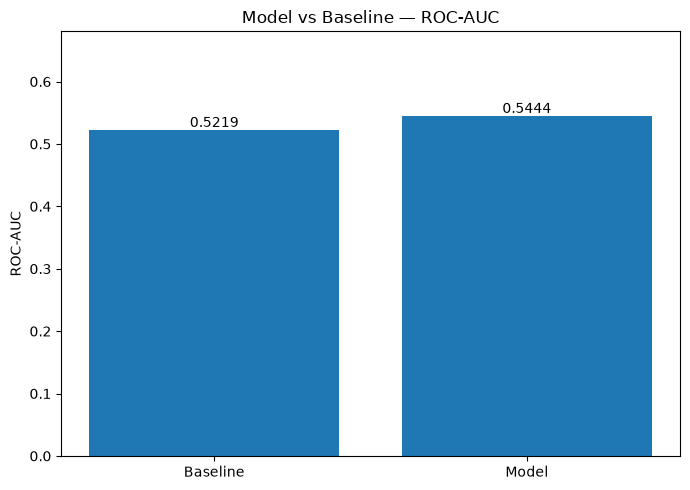

✅ Saved: /content/ml08_figures/01_model_vs_baseline_roc_auc.png


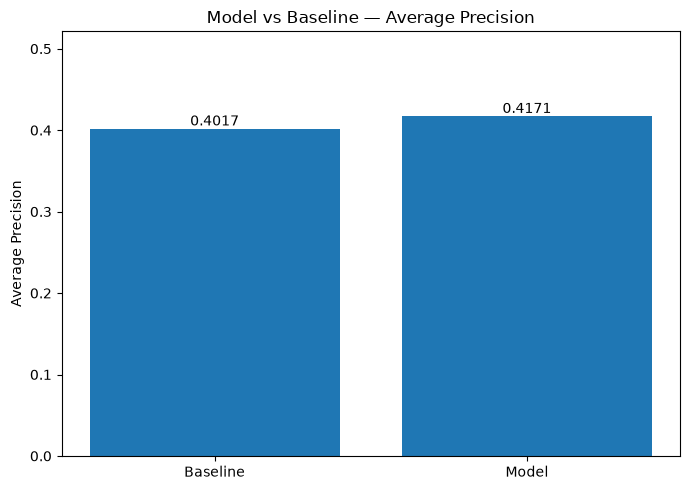

✅ Saved: /content/ml08_figures/02_model_vs_baseline_average_precision.png


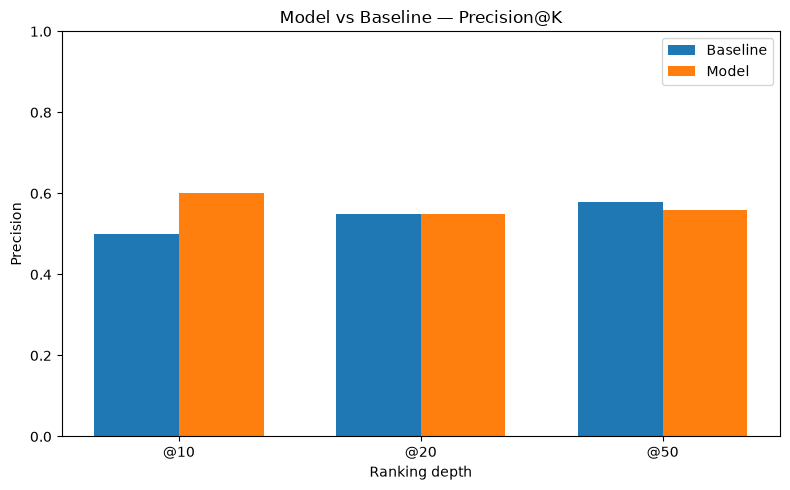

✅ Saved: /content/ml08_figures/03_model_vs_baseline_precision_at_k.png


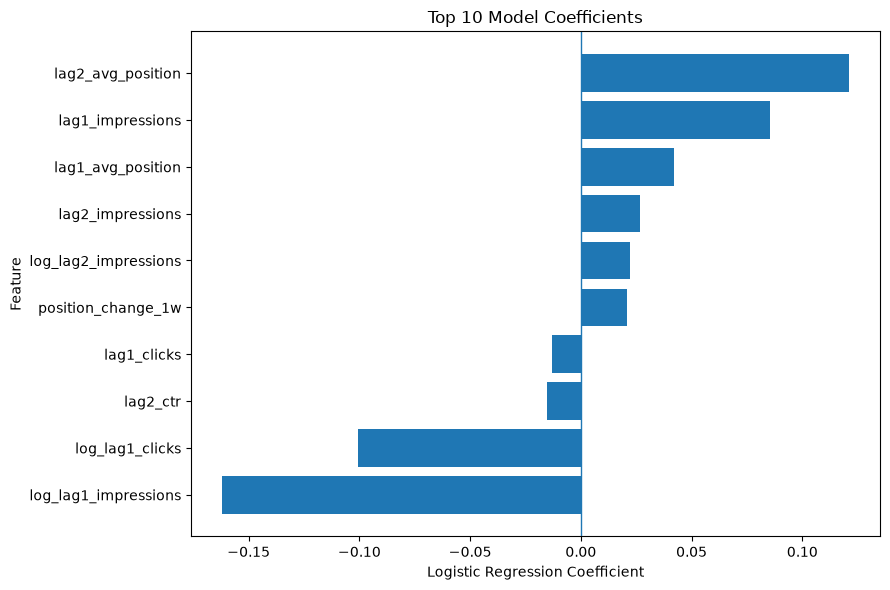

✅ Saved: /content/ml08_figures/04_top_model_coefficients.png


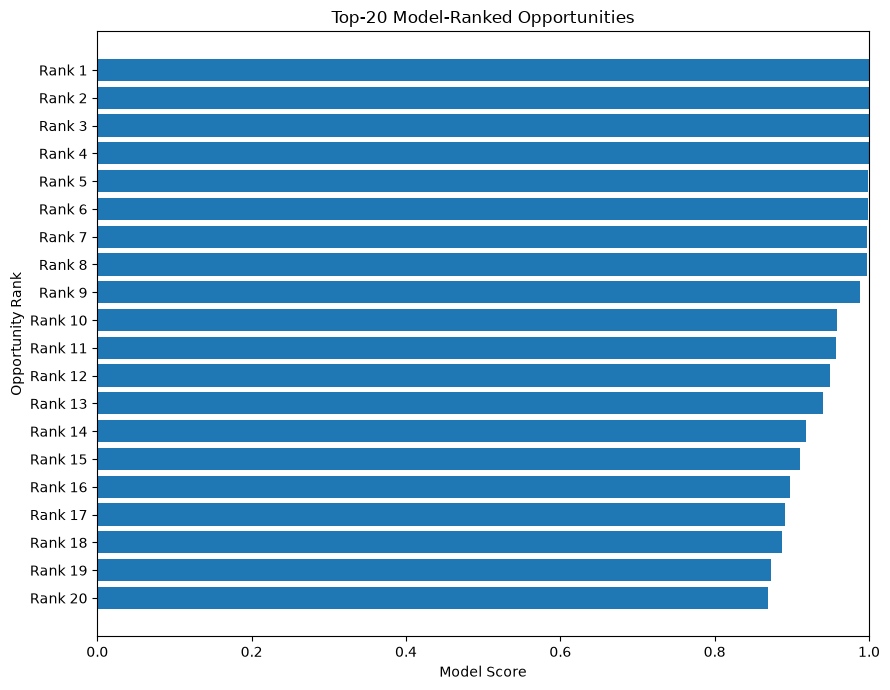

✅ Saved: /content/ml08_figures/05_top20_model_scores.png

📊 GENERATED FIGURES:
  • 01_model_vs_baseline_roc_auc.png (0.04 MB)
  • 02_model_vs_baseline_average_precision.png (0.04 MB)
  • 03_model_vs_baseline_precision_at_k.png (0.05 MB)
  • 04_top_model_coefficients.png (0.08 MB)
  • 05_top20_model_scores.png (0.09 MB)

Total figures: 5

✅ CELL 24 COMPLETED


In [19]:
# ============================================================
# CELL 24 — ML-08 RESULTS VISUALIZATION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("ML-08 — RESULTS VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

EVAL_PATH = Path(
    "/content/ml08_evaluation.csv"
)

COEF_PATH = Path(
    "/content/ml08_model_coefficients.csv"
)

TOP20_PATH = Path(
    "/content/ml08_top20_opportunities.csv"
)

FIGURES_DIR = Path(
    "/content/ml08_figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Validate files
# ------------------------------------------------------------

for path in [
    EVAL_PATH,
    COEF_PATH,
    TOP20_PATH
]:

    if not path.exists():
        raise FileNotFoundError(path)

print("✅ Required result files found.")

# ------------------------------------------------------------
# Load results
# ------------------------------------------------------------

evaluation = pd.read_csv(
    EVAL_PATH
)

coefficients = pd.read_csv(
    COEF_PATH
)

top20 = pd.read_csv(
    TOP20_PATH
)

print(
    f"Evaluation rows : {len(evaluation):,}"
)

print(
    f"Coefficient rows: {len(coefficients):,}"
)

print(
    f"Top-20 rows     : {len(top20):,}"
)

# ============================================================
# FIGURE 1 — ROC-AUC
# ============================================================

roc_row = evaluation[
    evaluation["metric"] == "ROC-AUC"
].iloc[0]

labels = [
    "Baseline",
    "Model"
]

values = [
    roc_row["baseline"],
    roc_row["model"]
]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    values
)

plt.ylabel("ROC-AUC")
plt.title("Model vs Baseline — ROC-AUC")
plt.ylim(
    0,
    max(values) * 1.25
)

for i, value in enumerate(values):

    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

roc_path = (
    FIGURES_DIR /
    "01_model_vs_baseline_roc_auc.png"
)

plt.savefig(
    roc_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"✅ Saved: {roc_path}"
)

# ============================================================
# FIGURE 2 — AVERAGE PRECISION
# ============================================================

ap_row = evaluation[
    evaluation["metric"] == "Average Precision"
].iloc[0]

values = [
    ap_row["baseline"],
    ap_row["model"]
]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    values
)

plt.ylabel("Average Precision")
plt.title("Model vs Baseline — Average Precision")
plt.ylim(
    0,
    max(values) * 1.25
)

for i, value in enumerate(values):

    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

ap_path = (
    FIGURES_DIR /
    "02_model_vs_baseline_average_precision.png"
)

plt.savefig(
    ap_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"✅ Saved: {ap_path}"
)

# ============================================================
# FIGURE 3 — PRECISION@K
# ============================================================

precision_k = evaluation[
    evaluation["metric"].str.startswith("Precision@")
].copy()

precision_k["k"] = (
    precision_k["metric"]
    .str.replace("Precision@", "", regex=False)
    .astype(int)
)

precision_k = precision_k.sort_values("k")

x = np.arange(
    len(precision_k)
)

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    precision_k["baseline"],
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    precision_k["model"],
    width,
    label="Model"
)

plt.xticks(
    x,
    [
        f"@{k}"
        for k in precision_k["k"]
    ]
)

plt.ylabel("Precision")
plt.xlabel("Ranking depth")
plt.title("Model vs Baseline — Precision@K")
plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

precision_path = (
    FIGURES_DIR /
    "03_model_vs_baseline_precision_at_k.png"
)

plt.savefig(
    precision_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"✅ Saved: {precision_path}"
)

# ============================================================
# FIGURE 4 — TOP MODEL COEFFICIENTS
# ============================================================

coef_plot = (
    coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .head(10)
    .sort_values(
        "coefficient"
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    coef_plot["feature"],
    coef_plot["coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Model Coefficients")

plt.axvline(
    0,
    linewidth=1
)

plt.tight_layout()

coef_path = (
    FIGURES_DIR /
    "04_top_model_coefficients.png"
)

plt.savefig(
    coef_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"✅ Saved: {coef_path}"
)

# ============================================================
# FIGURE 5 — TOP-20 MODEL SCORES
# ============================================================

top20_plot = top20.sort_values(
    "model_score",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    range(len(top20_plot)),
    top20_plot["model_score"]
)

plt.yticks(
    range(len(top20_plot)),
    [
        f"Rank {r}"
        for r in top20_plot["rank"]
    ]
)

plt.xlabel("Model Score")
plt.ylabel("Opportunity Rank")
plt.title("Top-20 Model-Ranked Opportunities")

plt.xlim(
    0,
    1
)

plt.tight_layout()

top20_path = (
    FIGURES_DIR /
    "05_top20_model_scores.png"
)

plt.savefig(
    top20_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"✅ Saved: {top20_path}"
)

# ============================================================
# FINAL FIGURE INVENTORY
# ============================================================

figure_files = sorted(
    FIGURES_DIR.glob("*.png")
)

print("\n📊 GENERATED FIGURES:")

for path in figure_files:

    size_mb = (
        path.stat().st_size /
        (1024 ** 2)
    )

    print(
        f"  • {path.name} "
        f"({size_mb:.2f} MB)"
    )

print(
    f"\nTotal figures: "
    f"{len(figure_files)}"
)

print("\n" + "=" * 70)
print("✅ CELL 24 COMPLETED")
print("=" * 70)

In [20]:
# ============================================================
# CELL 25 — ML-08 FINAL EVIDENCE & REPRODUCIBILITY AUDIT
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 70)
print("ML-08 — FINAL EVIDENCE & REPRODUCIBILITY AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

paths = {
    "weekly_clean": Path(
        "/content/ml08_weekly_clean.parquet"
    ),
    "features": Path(
        "/content/ml08_features.parquet"
    ),
    "modeling": Path(
        "/content/ml08_modeling.parquet"
    ),
    "train": Path(
        "/content/ml08_train.parquet"
    ),
    "test": Path(
        "/content/ml08_test.parquet"
    ),
    "baseline": Path(
        "/content/ml08_baseline_test.parquet"
    ),
    "model_scores": Path(
        "/content/ml08_model_scores.parquet"
    ),
    "evaluation": Path(
        "/content/ml08_evaluation.csv"
    ),
    "top20": Path(
        "/content/ml08_top20_opportunities.csv"
    ),
    "coefficients": Path(
        "/content/ml08_model_coefficients.csv"
    ),
    "model": Path(
        "/content/ml08_logistic_regression.joblib"
    )
}

# ------------------------------------------------------------
# File existence audit
# ------------------------------------------------------------

print("\n📁 FILE EXISTENCE AUDIT:")

file_status = []

for name, path in paths.items():

    exists = path.exists()

    file_status.append({
        "artifact": name,
        "exists": exists,
        "path": str(path)
    })

    status = "✅" if exists else "❌"

    print(
        f"{status} {name}: {path}"
    )

file_status_df = pd.DataFrame(file_status)

if not file_status_df["exists"].all():

    missing = file_status_df[
        ~file_status_df["exists"]
    ]

    raise FileNotFoundError(
        f"Missing artifacts:\n{missing}"
    )

print("\n✅ All core artifacts exist.")

# ============================================================
# DATASET AUDIT
# ============================================================

weekly = pd.read_parquet(
    paths["weekly_clean"]
)

modeling = pd.read_parquet(
    paths["modeling"]
)

train = pd.read_parquet(
    paths["train"]
)

test = pd.read_parquet(
    paths["test"]
)

print("\n📊 DATASET AUDIT:")

dataset_audit = pd.DataFrame([
    {
        "artifact": "weekly_clean",
        "rows": len(weekly),
        "weeks": weekly["week_start"].nunique(),
        "clients": weekly["client_hash_id"].nunique(),
        "contents": weekly["content_hash_id"].nunique(),
        "min_week": weekly["week_start"].min(),
        "max_week": weekly["week_start"].max()
    },
    {
        "artifact": "modeling",
        "rows": len(modeling),
        "weeks": modeling["week_start"].nunique(),
        "clients": modeling["client_hash_id"].nunique(),
        "contents": modeling["content_hash_id"].nunique(),
        "min_week": modeling["week_start"].min(),
        "max_week": modeling["week_start"].max()
    },
    {
        "artifact": "train",
        "rows": len(train),
        "weeks": train["week_start"].nunique(),
        "clients": train["client_hash_id"].nunique(),
        "contents": train["content_hash_id"].nunique(),
        "min_week": train["week_start"].min(),
        "max_week": train["week_start"].max()
    },
    {
        "artifact": "test",
        "rows": len(test),
        "weeks": test["week_start"].nunique(),
        "clients": test["client_hash_id"].nunique(),
        "contents": test["content_hash_id"].nunique(),
        "min_week": test["week_start"].min(),
        "max_week": test["week_start"].max()
    }
])

display(dataset_audit)

# ------------------------------------------------------------
# Temporal split audit
# ------------------------------------------------------------

latest_train = train["week_start"].max()
earliest_test = test["week_start"].min()

print(
    f"\nLatest train week : {latest_train}"
)

print(
    f"Earliest test week: {earliest_test}"
)

if latest_train >= earliest_test:

    raise ValueError(
        "Temporal split overlap detected."
    )

print(
    "✅ Temporal split is strictly chronological."
)

# ============================================================
# TARGET AUDIT
# ============================================================

positive_train = int(
    train["target"].sum()
)

positive_test = int(
    test["target"].sum()
)

train_rate = (
    positive_train / len(train)
)

test_rate = (
    positive_test / len(test)
)

target_audit = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train),
        "positive_cases": positive_train,
        "positive_rate": train_rate
    },
    {
        "split": "test",
        "rows": len(test),
        "positive_cases": positive_test,
        "positive_rate": test_rate
    }
])

print("\n🎯 TARGET AUDIT:")

display(
    target_audit.style.format({
        "positive_rate": "{:.2%}"
    })
)

# ============================================================
# MODEL EVALUATION AUDIT
# ============================================================

evaluation = pd.read_csv(
    paths["evaluation"]
)

print("\n📈 MODEL EVALUATION:")

display(
    evaluation.style.format({
        "baseline": "{:.6f}",
        "model": "{:.6f}",
        "absolute_improvement": "{:+.6f}",
        "relative_improvement_pct": "{:+.2f}%"
    })
)

# ============================================================
# TOP-20 AUDIT
# ============================================================

top20 = pd.read_csv(
    paths["top20"]
)

print("\n🏆 TOP-20 AUDIT:")

print(
    f"Rows: {len(top20):,}"
)

print(
    f"Latest week: {top20['week_start'].max()}"
)

print(
    f"Score range: "
    f"{top20['model_score'].min():.4f} → "
    f"{top20['model_score'].max():.4f}"
)

display(
    top20["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

# ============================================================
# COEFFICIENT AUDIT
# ============================================================

coefficients = pd.read_csv(
    paths["coefficients"]
)

print("\n🔍 COEFFICIENT AUDIT:")

print(
    f"Features analyzed: "
    f"{len(coefficients)}"
)

display(
    coefficients.head(10).style.format({
        "coefficient": "{:+.6f}",
        "absolute_coefficient": "{:.6f}"
    })
)

# ============================================================
# FIGURE AUDIT
# ============================================================

figures_dir = Path(
    "/content/ml08_figures"
)

figures = sorted(
    figures_dir.glob("*.png")
)

print("\n📊 FIGURE AUDIT:")

for figure in figures:

    print(
        f"✅ {figure.name}"
    )

if len(figures) != 5:

    raise ValueError(
        f"Expected 5 figures, found {len(figures)}."
    )

print(
    f"\n✅ Figure count verified: {len(figures)}"
)

# ============================================================
# FINAL AUDIT SUMMARY
# ============================================================

summary = {
    "core_artifacts": len(paths),
    "weekly_rows": len(weekly),
    "weekly_weeks": weekly["week_start"].nunique(),
    "modeling_rows": len(modeling),
    "train_rows": len(train),
    "test_rows": len(test),
    "train_positive_rate": train_rate,
    "test_positive_rate": test_rate,
    "evaluation_metrics": len(evaluation),
    "top20_rows": len(top20),
    "coefficient_count": len(coefficients),
    "figure_count": len(figures),
    "temporal_split_valid": True
}

summary_df = pd.DataFrame(
    [summary]
)

print("\n" + "=" * 70)
print("📋 FINAL ML-08 SUMMARY")
print("=" * 70)

display(
    summary_df.style.format({
        "train_positive_rate": "{:.2%}",
        "test_positive_rate": "{:.2%}"
    })
)

# ------------------------------------------------------------
# Save final audit
# ------------------------------------------------------------

AUDIT_PATH = Path(
    "/content/ml08_final_audit.csv"
)

summary_df.to_csv(
    AUDIT_PATH,
    index=False
)

print(
    f"\n✅ Final audit saved: {AUDIT_PATH}"
)

print("\n" + "=" * 70)
print("✅ CELL 25 COMPLETED")
print("=" * 70)

ML-08 — FINAL EVIDENCE & REPRODUCIBILITY AUDIT

📁 FILE EXISTENCE AUDIT:
✅ weekly_clean: /content/ml08_weekly_clean.parquet
✅ features: /content/ml08_features.parquet
✅ modeling: /content/ml08_modeling.parquet
✅ train: /content/ml08_train.parquet
✅ test: /content/ml08_test.parquet
✅ baseline: /content/ml08_baseline_test.parquet
✅ model_scores: /content/ml08_model_scores.parquet
✅ evaluation: /content/ml08_evaluation.csv
✅ top20: /content/ml08_top20_opportunities.csv
✅ coefficients: /content/ml08_model_coefficients.csv
✅ model: /content/ml08_logistic_regression.joblib

✅ All core artifacts exist.

📊 DATASET AUDIT:


,artifact,rows,weeks,clients,contents,min_week,max_week
0,weekly_clean,13604148,75,70,427292,2025-01-27,2026-06-29
1,modeling,2445230,67,58,182381,2025-02-03,2026-06-22
2,train,1094745,53,43,101424,2025-02-03,2026-03-02
3,test,1350485,14,52,167162,2026-03-09,2026-06-22



Latest train week : 2026-03-02
Earliest test week: 2026-03-09
✅ Temporal split is strictly chronological.

🎯 TARGET AUDIT:


,split,rows,positive_cases,positive_rate
0,train,1094745,278077,25.40%
1,test,1350485,520713,38.56%



📈 MODEL EVALUATION:


...


🔍 COEFFICIENT AUDIT:
Features analyzed: 15


,rank,feature,coefficient,absolute_coefficient,direction
0,1,log_lag1_impressions,-0.161934,0.161934,Negative
1,2,lag2_avg_position,+0.120920,0.120920,Positive
2,3,log_lag1_clicks,-0.100465,0.100465,Negative
3,4,lag1_impressions,+0.085334,0.085334,Positive
4,5,lag1_avg_position,+0.042181,0.042181,Positive
5,6,lag2_impressions,+0.026620,0.026620,Positive
6,7,log_lag2_impressions,+0.021979,0.021979,Positive
7,8,position_change_1w,+0.020801,0.020801,Positive
8,9,lag2_ctr,-0.015313,0.015313,Negative
9,10,lag1_clicks,-0.012902,0.012902,Negative



📊 FIGURE AUDIT:
✅ 01_model_vs_baseline_roc_auc.png
✅ 02_model_vs_baseline_average_precision.png
✅ 03_model_vs_baseline_precision_at_k.png
✅ 04_top_model_coefficients.png
✅ 05_top20_model_scores.png

✅ Figure count verified: 5

📋 FINAL ML-08 SUMMARY


,core_artifacts,weekly_rows,weekly_weeks,modeling_rows,train_rows,test_rows,train_positive_rate,test_positive_rate,evaluation_metrics,top20_rows,coefficient_count,figure_count,temporal_split_valid
0,11,13604148,75,2445230,1094745,1350485,25.40%,38.56%,5,20,15,5,True



✅ Final audit saved: /content/ml08_final_audit.csv

✅ CELL 25 COMPLETED


In [21]:
# ============================================================
# ML-08 — TARGET CONSISTENCY AUDIT
# ============================================================

import duckdb
import pandas as pd
import numpy as np

print("=" * 70)
print("ML-08 — TARGET CONSISTENCY AUDIT")
print("=" * 70)

con = duckdb.connect(database=":memory:")

test_path = "/content/ml08_test.parquet"

# Load only the columns needed for the audit
df = con.execute(f"""
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        impression_change_1w,
        target
    FROM read_parquet('{test_path}')
""").df()

print(f"Test rows: {len(df):,}")

# ------------------------------------------------------------
# Expected target from the documented definition:
# target = 1 when current-week impressions <= 80% of previous week
# which corresponds to impression_change_1w <= -20%
# ------------------------------------------------------------

df["expected_target"] = (
    df["impression_change_1w"].notna()
    & (df["impression_change_1w"] <= -0.20)
).astype(int)

# Compare actual vs expected
df["target_match"] = (
    df["target"].astype(int) == df["expected_target"]
)

mismatches = df.loc[~df["target_match"]].copy()

print()
print("🎯 TARGET DEFINITION CHECK")
print("-" * 70)

print(f"Actual positive cases   : {df['target'].sum():,}")
print(f"Expected positive cases : {df['expected_target'].sum():,}")
print(f"Target mismatches       : {len(mismatches):,}")
print(
    f"Target agreement        : "
    f"{df['target_match'].mean() * 100:.4f}%"
)

# ------------------------------------------------------------
# Check whether any target=1 has impression_change > -20%
# ------------------------------------------------------------

contradictions = df[
    (df["target"] == 1) &
    (
        df["impression_change_1w"].isna() |
        (df["impression_change_1w"] > -0.20)
    )
].copy()

print()
print("🔎 CONTRADICTION CHECK")
print("-" * 70)
print(
    f"Target=1 but change is NOT <= -20%: "
    f"{len(contradictions):,}"
)

# ------------------------------------------------------------
# Check target=0 with <= -20%
# ------------------------------------------------------------

reverse_contradictions = df[
    (df["target"] == 0) &
    df["impression_change_1w"].notna() &
    (df["impression_change_1w"] <= -0.20)
].copy()

print(
    f"Target=0 but change IS <= -20%: "
    f"{len(reverse_contradictions):,}"
)

# ------------------------------------------------------------
# Show examples if mismatches exist
# ------------------------------------------------------------

if len(mismatches) > 0:
    print()
    print("⚠️ SAMPLE TARGET MISMATCHES")
    print("-" * 70)

    display(
        mismatches[
            [
                "week_start",
                "client_hash_id",
                "content_hash_id",
                "impression_change_1w",
                "target",
                "expected_target",
            ]
        ].head(20)
    )
else:
    print()
    print("✅ No target-definition mismatches found.")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print()
print("=" * 70)

if len(mismatches) == 0:
    print("✅ TARGET CONSISTENCY PASSED")
    print("The target matches the documented >=20% decline definition.")
else:
    print("❌ TARGET CONSISTENCY FAILED")
    print("Do NOT finalize the paper until the target construction is corrected.")

print("=" * 70)

ML-08 — TARGET CONSISTENCY AUDIT
Test rows: 1,350,485

🎯 TARGET DEFINITION CHECK
----------------------------------------------------------------------
Actual positive cases   : 520,713
Expected positive cases : 300,006
Target mismatches       : 573,279
Target agreement        : 57.5501%

🔎 CONTRADICTION CHECK
----------------------------------------------------------------------
Target=1 but change is NOT <= -20%: 396,993
Target=0 but change IS <= -20%: 176,286

⚠️ SAMPLE TARGET MISMATCHES
----------------------------------------------------------------------


,week_start,client_hash_id,content_hash_id,impression_change_1w,target,expected_target
1,2026-03-09,client_0797ff3a1fc9a6a5,content_05acc92c165f4386,2.714286,1,0
3,2026-03-09,client_0797ff3a1fc9a6a5,content_1207efddce873942,0.418182,1,0
4,2026-03-09,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,12.333333,1,0
9,2026-03-09,client_0797ff3a1fc9a6a5,content_a7a5f0d74ec03ce8,0.155030,1,0
10,2026-03-09,client_0797ff3a1fc9a6a5,content_be06033d30b49299,0.843750,1,0
11,2026-03-09,client_0797ff3a1fc9a6a5,content_c89645311e3a5d17,1.888889,1,0
14,2026-03-09,client_08a6a72ff48e62c0,content_000eb7dc8f73e13b,NaN,1,0
21,2026-03-09,client_08a6a72ff48e62c0,content_004cba86860ab130,-0.300000,0,1
27,2026-03-09,client_08a6a72ff48e62c0,content_0064ab0f90808e34,-0.294118,0,1
28,2026-03-09,client_08a6a72ff48e62c0,content_007149fbbe367e35,8.000000,1,0



❌ TARGET CONSISTENCY FAILED
Do NOT finalize the paper until the target construction is corrected.


In [23]:
# ============================================================
# ML-08 — TARGET CONSTRUCTION DIAGNOSTIC — FIXED
# ============================================================

import duckdb
import pandas as pd
import numpy as np

print("=" * 70)
print("ML-08 — TARGET CONSTRUCTION DIAGNOSTIC — FIXED")
print("=" * 70)

con = duckdb.connect(database=":memory:")

modeling_path = "/content/ml08_modeling.parquet"

# ------------------------------------------------------------
# 1. Load only columns that actually exist in modeling dataset
# ------------------------------------------------------------

df = con.execute(f"""
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        lag1_impressions,
        lag2_impressions,
        lag3_impressions,
        lag1_clicks,
        lag2_clicks,
        lag1_ctr,
        lag2_ctr,
        lag1_avg_position,
        lag2_avg_position,
        impression_change_1w,
        impression_change_prev_1w,
        position_change_1w,
        target
    FROM read_parquet('{modeling_path}')
""").df()

print(f"\nRows: {len(df):,}")

# ------------------------------------------------------------
# 2. Reconstruct current impressions from lag1 + change
#
# impression_change_1w =
#     (current - previous) / previous
#
# therefore:
# current = previous * (1 + change)
# ------------------------------------------------------------

df["reconstructed_current_impressions"] = (
    df["lag1_impressions"] *
    (1.0 + df["impression_change_1w"])
)

# ------------------------------------------------------------
# 3. Expected target from documented definition
#
# target = 1 when current impressions <= 80%
# of previous-week impressions
# ------------------------------------------------------------

df["expected_target"] = (
    df["impression_change_1w"].notna()
    & (df["impression_change_1w"] <= -0.20)
).astype(int)

# ------------------------------------------------------------
# 4. Compare actual target with expected target
# ------------------------------------------------------------

df["target_match"] = (
    df["target"].astype(int)
    ==
    df["expected_target"]
)

mismatches = df[~df["target_match"]].copy()

print("\n🎯 TARGET DEFINITION CHECK")
print("-" * 70)

print(f"Actual positive cases   : {df['target'].sum():,}")
print(f"Expected positive cases : {df['expected_target'].sum():,}")
print(f"Target mismatches       : {len(mismatches):,}")
print(
    f"Target agreement        : "
    f"{df['target_match'].mean() * 100:.4f}%"
)

# ------------------------------------------------------------
# 5. Contradiction checks
# ------------------------------------------------------------

contradictions = df[
    (df["target"] == 1) &
    (
        df["impression_change_1w"].isna() |
        (df["impression_change_1w"] > -0.20)
    )
]

reverse_contradictions = df[
    (df["target"] == 0) &
    df["impression_change_1w"].notna() &
    (df["impression_change_1w"] <= -0.20)
]

print("\n🔎 CONTRADICTION CHECK")
print("-" * 70)

print(
    f"Target=1 but change is NOT <= -20%: "
    f"{len(contradictions):,}"
)

print(
    f"Target=0 but change IS <= -20%: "
    f"{len(reverse_contradictions):,}"
)

# ------------------------------------------------------------
# 6. Check relationship between change and lag1 impressions
# ------------------------------------------------------------

valid_ratio = df[
    df["lag1_impressions"].notna() &
    (df["lag1_impressions"] > 0) &
    df["impression_change_1w"].notna()
].copy()

valid_ratio["reconstructed_ratio"] = (
    valid_ratio["reconstructed_current_impressions"]
    / valid_ratio["lag1_impressions"]
)

print("\n📐 CHANGE FORMULA AUDIT")
print("-" * 70)

print(f"Rows with valid previous impressions: {len(valid_ratio):,}")

if len(valid_ratio) > 0:
    print(
        "Expected current/previous ratio range: "
        f"{valid_ratio['reconstructed_ratio'].min():.6f} → "
        f"{valid_ratio['reconstructed_ratio'].max():.6f}"
    )

# ------------------------------------------------------------
# 7. Show mismatches
# ------------------------------------------------------------

if len(mismatches) > 0:

    print("\n⚠️ SAMPLE TARGET MISMATCHES")
    print("-" * 70)

    display(
        mismatches[[
            "week_start",
            "client_hash_id",
            "content_hash_id",
            "lag1_impressions",
            "impression_change_1w",
            "target",
            "expected_target"
        ]].head(20)
    )

else:

    print("\n✅ No target-definition mismatches found.")

# ------------------------------------------------------------
# 8. Distribution of impression change by actual target
# ------------------------------------------------------------

print("\n📊 IMPRESSION CHANGE BY ACTUAL TARGET")
print("-" * 70)

distribution = (
    df.groupby("target")["impression_change_1w"]
      .describe(
          percentiles=[
              0.01,
              0.05,
              0.25,
              0.50,
              0.75,
              0.95,
              0.99
          ]
      )
)

display(distribution)

print("\n" + "=" * 70)

if len(mismatches) == 0:
    print("✅ TARGET CONSISTENCY PASSED")
else:
    print("❌ TARGET CONSISTENCY FAILED")

print("=" * 70)

ML-08 — TARGET CONSTRUCTION DIAGNOSTIC — FIXED


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Rows: 2,445,230

🎯 TARGET DEFINITION CHECK
----------------------------------------------------------------------
Actual positive cases   : 798,790
Expected positive cases : 446,489
Target mismatches       : 912,183
Target agreement        : 62.6954%

🔎 CONTRADICTION CHECK
----------------------------------------------------------------------
Target=1 but change is NOT <= -20%: 632,242
Target=0 but change IS <= -20%: 279,941

📐 CHANGE FORMULA AUDIT
----------------------------------------------------------------------
Rows with valid previous impressions: 2,370,970
Expected current/previous ratio range: 0.000474 → 9811.000000

⚠️ SAMPLE TARGET MISMATCHES
----------------------------------------------------------------------


,week_start,client_hash_id,content_hash_id,lag1_impressions,impression_change_1w,target,expected_target
12,2025-02-03,client_9958f0a7ae1df715,content_5177491e13f7b668,53.0,3.818182,1,0
29,2025-02-03,client_9958f0a7ae1df715,content_a9abaa2801941235,30.0,-0.433962,0,1
79,2025-02-10,client_9958f0a7ae1df715,content_0c26783e8437e75f,22.0,NaN,1,0
82,2025-02-10,client_9958f0a7ae1df715,content_0ca502c18c4fd41e,29.0,0.318182,1,0
84,2025-02-10,client_9958f0a7ae1df715,content_0d308caf94a3ed16,101.0,0.160920,1,0
98,2025-02-10,client_9958f0a7ae1df715,content_13802b3937c7bb5a,98.0,23.500000,1,0
122,2025-02-10,client_9958f0a7ae1df715,content_1ee0c6c1c97fc6af,38.0,NaN,1,0
134,2025-02-10,client_9958f0a7ae1df715,content_22da67ec74ea61cb,503.0,NaN,1,0
148,2025-02-10,client_9958f0a7ae1df715,content_28882d188c03a092,24.0,NaN,1,0
175,2025-02-10,client_9958f0a7ae1df715,content_336125a54dcd49e5,60.0,29.000000,1,0



📊 IMPRESSION CHANGE BY ACTUAL TARGET
----------------------------------------------------------------------


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
target,,,,,,,,,,,,
0,1589377.0,1.694076,18.838258,-0.999526,-0.684685,-0.45614,-0.105784,0.217207,1.142857,6.300000,18.333333,9104.0
1,781593.0,1.728861,20.701448,-0.997981,-0.718058,-0.50170,-0.151351,0.171429,0.915584,6.899047,23.400000,9810.0



❌ TARGET CONSISTENCY FAILED


In [3]:
# ============================================================
# ML-08 — FEATURE DUPLICATION AUDIT
# ============================================================

import duckdb
import pandas as pd
import numpy as np

print("=" * 70)
print("ML-08 — FEATURE DUPLICATION AUDIT")
print("=" * 70)

con = duckdb.connect(database=":memory:")

features_path = "/content/ml08_features.parquet"
weekly_path = "/content/ml08_weekly_clean.parquet"

# ------------------------------------------------------------
# 0. Inspect schemas
# ------------------------------------------------------------

weekly_schema = con.execute(f"""
    DESCRIBE SELECT *
    FROM read_parquet('{weekly_path}')
""").df()

features_schema = con.execute(f"""
    DESCRIBE SELECT *
    FROM read_parquet('{features_path}')
""").df()

print("\n📋 FEATURES SCHEMA")
print("-" * 70)
display(features_schema)

# ------------------------------------------------------------
# 1. Check uniqueness of weekly_clean
# ------------------------------------------------------------

weekly_key_audit = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT
            CAST(week_start AS VARCHAR) || '|' ||
            CAST(client_hash_id AS VARCHAR) || '|' ||
            CAST(content_hash_id AS VARCHAR)
        ) AS unique_keys
    FROM read_parquet('{weekly_path}')
""").df()

weekly_key_audit["duplicate_rows"] = (
    weekly_key_audit["total_rows"]
    - weekly_key_audit["unique_keys"]
)

print("\n📊 WEEKLY CLEAN KEY AUDIT")
print("-" * 70)
display(weekly_key_audit)

# ------------------------------------------------------------
# 2. Check uniqueness of features
# ------------------------------------------------------------

feature_key_audit = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT
            CAST(week_start AS VARCHAR) || '|' ||
            CAST(client_hash_id AS VARCHAR) || '|' ||
            CAST(content_hash_id AS VARCHAR)
        ) AS unique_keys
    FROM read_parquet('{features_path}')
""").df()

feature_key_audit["duplicate_rows"] = (
    feature_key_audit["total_rows"]
    - feature_key_audit["unique_keys"]
)

print("\n📊 FEATURES KEY AUDIT")
print("-" * 70)
display(feature_key_audit)

# ------------------------------------------------------------
# 3. Number of duplicate groups
# ------------------------------------------------------------

duplicate_groups = con.execute(f"""
    SELECT COUNT(*) AS duplicate_groups
    FROM (
        SELECT
            week_start,
            client_hash_id,
            content_hash_id
        FROM read_parquet('{features_path}')
        GROUP BY
            week_start,
            client_hash_id,
            content_hash_id
        HAVING COUNT(*) > 1
    )
""").fetchone()[0]

print(f"\nDuplicate key groups: {duplicate_groups:,}")

# ------------------------------------------------------------
# 4. Distribution of rows per duplicate key
# ------------------------------------------------------------

dup_distribution = con.execute(f"""
    SELECT
        row_count,
        COUNT(*) AS number_of_keys
    FROM (
        SELECT
            week_start,
            client_hash_id,
            content_hash_id,
            COUNT(*) AS row_count
        FROM read_parquet('{features_path}')
        GROUP BY
            week_start,
            client_hash_id,
            content_hash_id
        HAVING COUNT(*) > 1
    )
    GROUP BY row_count
    ORDER BY row_count
""").df()

print("\n📈 DUPLICATE MULTIPLICITY")
print("-" * 70)
display(dup_distribution)

# ------------------------------------------------------------
# 5. Inspect one duplicated key
# ------------------------------------------------------------

duplicate_example = con.execute(f"""
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        COUNT(*) AS row_count
    FROM read_parquet('{features_path}')
    GROUP BY
        week_start,
        client_hash_id,
        content_hash_id
    HAVING COUNT(*) > 1
    ORDER BY row_count DESC
    LIMIT 1
""").df()

print("\n🔎 MOST DUPLICATED KEY")
print("-" * 70)
display(duplicate_example)

# ------------------------------------------------------------
# 6. Show all rows for that key
# ------------------------------------------------------------

if len(duplicate_example) > 0:

    wk = duplicate_example.iloc[0]["week_start"]
    client = duplicate_example.iloc[0]["client_hash_id"]
    content = duplicate_example.iloc[0]["content_hash_id"]

    example_rows = con.execute(f"""
        SELECT *
        FROM read_parquet('{features_path}')
        WHERE week_start = ?
          AND client_hash_id = ?
          AND content_hash_id = ?
        ORDER BY week_start
    """, [wk, client, content]).df()

    print("\n📋 DUPLICATED ROW CONTENT")
    print("-" * 70)
    display(example_rows)

else:
    print("\n✅ No duplicated feature keys found.")

# ------------------------------------------------------------
# 7. Determine whether duplicated rows are identical
# ------------------------------------------------------------

# Get all columns except the business key.
feature_columns = [
    row["column_name"]
    for _, row in features_schema.iterrows()
    if row["column_name"] not in {
        "week_start",
        "client_hash_id",
        "content_hash_id"
    }
]

if duplicate_groups > 0 and feature_columns:

    # Build a deterministic row fingerprint using DuckDB's hash().
    # This checks the complete feature payload rather than only
    # a few manually selected feature columns.

    feature_struct = ", ".join(
        f'"{col}"' for col in feature_columns
    )

    identical_audit = con.execute(f"""
        WITH duplicated_keys AS (
            SELECT
                week_start,
                client_hash_id,
                content_hash_id
            FROM read_parquet('{features_path}')
            GROUP BY
                week_start,
                client_hash_id,
                content_hash_id
            HAVING COUNT(*) > 1
        ),

        duplicated_rows AS (
            SELECT f.*
            FROM read_parquet('{features_path}') f
            INNER JOIN duplicated_keys d
                ON f.week_start = d.week_start
               AND f.client_hash_id = d.client_hash_id
               AND f.content_hash_id = d.content_hash_id
        )

        SELECT
            COUNT(*) AS duplicate_rows,

            COUNT(
                DISTINCT hash(
                    {feature_struct}
                )
            ) AS distinct_feature_payloads

        FROM duplicated_rows
    """).df()

    print("\n🧬 DUPLICATE CONTENT AUDIT")
    print("-" * 70)
    display(identical_audit)

else:

    identical_audit = pd.DataFrame([{
        "duplicate_rows": 0,
        "distinct_feature_payloads": 0
    }])

    print("\n🧬 DUPLICATE CONTENT AUDIT")
    print("-" * 70)
    display(identical_audit)

# ------------------------------------------------------------
# 8. Check whether duplicates are concentrated by week
# ------------------------------------------------------------

dup_by_week = con.execute(f"""
    SELECT
        week_start,
        COUNT(*) AS total_rows,

        COUNT(DISTINCT
            CAST(client_hash_id AS VARCHAR) || '|' ||
            CAST(content_hash_id AS VARCHAR)
        ) AS unique_content_client_keys

    FROM read_parquet('{features_path}')
    GROUP BY week_start
    ORDER BY week_start
""").df()

dup_by_week["duplicate_rows"] = (
    dup_by_week["total_rows"]
    - dup_by_week["unique_content_client_keys"]
)

dup_by_week["duplicate_pct"] = np.where(
    dup_by_week["total_rows"] > 0,
    dup_by_week["duplicate_rows"]
    / dup_by_week["total_rows"]
    * 100,
    0
)

print("\n📅 DUPLICATES BY WEEK")
print("-" * 70)
display(dup_by_week)

# ------------------------------------------------------------
# 9. Final audit conclusion
# ------------------------------------------------------------

feature_total = int(feature_key_audit.iloc[0]["total_rows"])
feature_unique = int(feature_key_audit.iloc[0]["unique_keys"])
feature_duplicate_rows = feature_total - feature_unique

print("\n" + "=" * 70)
print("AUDIT CONCLUSION")
print("=" * 70)

if feature_duplicate_rows == 0:
    print("✅ PASS — Features are unique at the declared grain:")
    print("   week_start × client_hash_id × content_hash_id")
else:
    print("⚠️ DUPLICATION DETECTED")
    print(f"   Total feature rows: {feature_total:,}")
    print(f"   Unique feature keys: {feature_unique:,}")
    print(f"   Duplicate rows: {feature_duplicate_rows:,}")
    print(f"   Duplicate key groups: {duplicate_groups:,}")

print("=" * 70)
print("✅ FEATURE DUPLICATION AUDIT COMPLETED")
print("=" * 70)

ML-08 — FEATURE DUPLICATION AUDIT

📋 FEATURES SCHEMA
----------------------------------------------------------------------


,column_name,column_type,null,key,default,extra
0,week_start,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,observed_days,BIGINT,YES,None,None,None
4,gsc_available_days,DOUBLE,YES,None,None,None
5,impressions,DOUBLE,YES,None,None,None
6,clicks,DOUBLE,YES,None,None,None
7,ctr,DOUBLE,YES,None,None,None
8,avg_position,DOUBLE,YES,None,None,None
9,lag1_impressions,DOUBLE,YES,None,None,None


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📊 WEEKLY CLEAN KEY AUDIT
----------------------------------------------------------------------


,total_rows,unique_keys,duplicate_rows
0,13604148,11925499,1678649


...

,duplicate_rows,distinct_feature_payloads
0,3357298,1581267


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📅 DUPLICATES BY WEEK
----------------------------------------------------------------------


,week_start,total_rows,unique_content_client_keys,duplicate_rows,duplicate_pct
0,2025-01-27,808,557,251,31.064356
1,2025-02-03,2036,2036,0,0.000000
2,2025-02-10,3640,3640,0,0.000000
3,2025-02-17,4967,4967,0,0.000000
4,2025-02-24,9301,5049,4252,45.715514
...,...,...,...,...,...
70,2026-06-01,395197,395197,0,0.000000
71,2026-06-08,399176,399176,0,0.000000
72,2026-06-15,403079,403079,0,0.000000
73,2026-06-22,409205,409205,0,0.000000



AUDIT CONCLUSION
⚠️ DUPLICATION DETECTED
   Total feature rows: 13,604,148
   Unique feature keys: 11,925,499
   Duplicate rows: 1,678,649
   Duplicate key groups: 1,678,649
✅ FEATURE DUPLICATION AUDIT COMPLETED


In [4]:
# ============================================================
# ML-08 — GRAIN DIAGNOSTIC
# ============================================================

import duckdb
import pandas as pd

print("=" * 70)
print("ML-08 — GRAIN DIAGNOSTIC")
print("=" * 70)

con = duckdb.connect(database=":memory:")

weekly_path = "/content/ml08_weekly_clean.parquet"

# ------------------------------------------------------------
# 1. Show weekly_clean schema
# ------------------------------------------------------------

schema = con.execute(f"""
    DESCRIBE SELECT *
    FROM read_parquet('{weekly_path}')
""").df()

print("\n📋 WEEKLY CLEAN SCHEMA")
print("-" * 70)
display(schema)

columns = schema["column_name"].tolist()

print(f"\nTotal columns: {len(columns)}")

# ------------------------------------------------------------
# 2. Find duplicated declared keys
# ------------------------------------------------------------

duplicate_keys = con.execute(f"""
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        COUNT(*) AS row_count
    FROM read_parquet('{weekly_path}')
    GROUP BY
        week_start,
        client_hash_id,
        content_hash_id
    HAVING COUNT(*) > 1
    ORDER BY row_count DESC
    LIMIT 10
""").df()

print("\n🔎 SAMPLE DUPLICATED KEYS")
print("-" * 70)
display(duplicate_keys)

# ------------------------------------------------------------
# 3. Show all rows for the first duplicated key
# ------------------------------------------------------------

if len(duplicate_keys) > 0:

    wk = duplicate_keys.iloc[0]["week_start"]
    client = duplicate_keys.iloc[0]["client_hash_id"]
    content = duplicate_keys.iloc[0]["content_hash_id"]

    sample_rows = con.execute(f"""
        SELECT *
        FROM read_parquet('{weekly_path}')
        WHERE week_start = ?
          AND client_hash_id = ?
          AND content_hash_id = ?
        ORDER BY ALL
    """, [wk, client, content]).df()

    print("\n📋 FULL DUPLICATED RECORD")
    print("-" * 70)
    display(sample_rows)

else:
    print("\n✅ No duplicated declared keys found.")

# ------------------------------------------------------------
# 4. Automatically test individual columns
# ------------------------------------------------------------

base_keys = {
    "week_start",
    "client_hash_id",
    "content_hash_id"
}

candidate_columns = [
    c for c in columns
    if c not in base_keys
]

diagnostics = []

for col in candidate_columns:

    # Safely quote column name
    quoted = '"' + col.replace('"', '""') + '"'

    try:
        result = con.execute(f"""
            WITH duplicated_keys AS (
                SELECT
                    week_start,
                    client_hash_id,
                    content_hash_id
                FROM read_parquet('{weekly_path}')
                GROUP BY
                    week_start,
                    client_hash_id,
                    content_hash_id
                HAVING COUNT(*) > 1
            ),

            duplicated_rows AS (
                SELECT w.*
                FROM read_parquet('{weekly_path}') w
                INNER JOIN duplicated_keys d
                    ON w.week_start = d.week_start
                   AND w.client_hash_id = d.client_hash_id
                   AND w.content_hash_id = d.content_hash_id
            ),

            grouped AS (
                SELECT
                    week_start,
                    client_hash_id,
                    content_hash_id,
                    COUNT(DISTINCT {quoted}) AS distinct_values
                FROM duplicated_rows
                GROUP BY
                    week_start,
                    client_hash_id,
                    content_hash_id
            )

            SELECT
                COUNT(*) AS duplicate_groups,
                COUNT(*) FILTER (
                    WHERE distinct_values > 1
                ) AS groups_distinguished_by_column
            FROM grouped
        """).fetchone()

        diagnostics.append({
            "column": col,
            "duplicate_groups": result[0],
            "groups_distinguished_by_column": result[1],
            "distinguishing_pct": (
                result[1] / result[0] * 100
                if result[0] else 0
            )
        })

    except Exception as e:

        diagnostics.append({
            "column": col,
            "duplicate_groups": None,
            "groups_distinguished_by_column": None,
            "distinguishing_pct": None,
            "error": str(e)
        })

diagnostics_df = pd.DataFrame(diagnostics)

# ------------------------------------------------------------
# 5. Rank columns by ability to distinguish duplicates
# ------------------------------------------------------------

if "distinguishing_pct" in diagnostics_df.columns:

    diagnostics_df = diagnostics_df.sort_values(
        "distinguishing_pct",
        ascending=False,
        na_position="last"
    )

print("\n🧬 CANDIDATE GRAIN COLUMNS")
print("-" * 70)
display(diagnostics_df)

# ------------------------------------------------------------
# 6. Test likely additional grain columns
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🔍 GRAIN DIAGNOSTIC COMPLETE")
print("=" * 70)

if len(diagnostics_df) > 0:

    top = diagnostics_df.dropna(
        subset=["distinguishing_pct"]
    ).head(10)

    print("\nTop candidate columns:")
    for _, row in top.iterrows():
        print(
            f"  {row['column']}: "
            f"{row['distinguishing_pct']:.2f}% of duplicate groups distinguished"
        )

print("\n⚠️ Do NOT delete duplicates yet.")
print("⚠️ Do NOT change the feature grain yet.")
print("The next step depends on this diagnostic.")
print("=" * 70)

ML-08 — GRAIN DIAGNOSTIC

📋 WEEKLY CLEAN SCHEMA
----------------------------------------------------------------------


,column_name,column_type,null,key,default,extra
0,week_start,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,observed_days,BIGINT,YES,None,None,None
4,gsc_available_days,DOUBLE,YES,None,None,None
5,impressions,DOUBLE,YES,None,None,None
6,clicks,DOUBLE,YES,None,None,None
7,ctr,DOUBLE,YES,None,None,None
8,avg_position,DOUBLE,YES,None,None,None



Total columns: 9


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


🔎 SAMPLE DUPLICATED KEYS
----------------------------------------------------------------------


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


🧬 CANDIDATE GRAIN COLUMNS
----------------------------------------------------------------------


,column,duplicate_groups,groups_distinguished_by_column,distinguishing_pct
0,observed_days,1678649,1662930,99.063592
2,impressions,1678649,768951,45.807730
1,gsc_available_days,1678649,746667,44.480234
5,avg_position,1678649,683117,40.694451
4,ctr,1678649,201751,12.018653
3,clicks,1678649,186619,11.117214



🔍 GRAIN DIAGNOSTIC COMPLETE

Top candidate columns:
  observed_days: 99.06% of duplicate groups distinguished
  impressions: 45.81% of duplicate groups distinguished
  gsc_available_days: 44.48% of duplicate groups distinguished
  avg_position: 40.69% of duplicate groups distinguished
  ctr: 12.02% of duplicate groups distinguished
  clicks: 11.12% of duplicate groups distinguished

⚠️ Do NOT delete duplicates yet.
⚠️ Do NOT change the feature grain yet.
The next step depends on this diagnostic.


In [5]:
# ============================================================
# ML-08 — TRACE WEEKLY CLEAN CONSTRUCTION
# ============================================================

import os
import glob

print("=" * 70)
print("SEARCHING FOR ML-08 / WEEKLY CLEAN NOTEBOOKS")
print("=" * 70)

# Search common Colab locations
patterns = [
    "/content/**/*.ipynb",
    "/content/**/*.py"
]

files = []

for pattern in patterns:
    files.extend(glob.glob(pattern, recursive=True))

# Remove duplicates
files = sorted(set(files))

print(f"\nFound {len(files)} notebook/python files.")

for f in files:
    name = os.path.basename(f).lower()

    if (
        "ml08" in name
        or "weekly" in name
        or "feature" in name
        or "clean" in name
    ):
        print(f"  → {f}")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

SEARCHING FOR ML-08 / WEEKLY CLEAN NOTEBOOKS

Found 0 notebook/python files.

DONE


In [6]:
# ============================================================
# ML-08 — WEEKLY CLEAN DUPLICATE DIAGNOSTIC
# ============================================================

import duckdb
import pandas as pd
import numpy as np

print("=" * 70)
print("ML-08 — WEEKLY CLEAN DUPLICATE DIAGNOSTIC")
print("=" * 70)

con = duckdb.connect(database=":memory:")

weekly_path = "/content/ml08_weekly_clean.parquet"

# ------------------------------------------------------------
# 1. Overall duplicate statistics
# ------------------------------------------------------------

overall = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT
            week_start || '|' ||
            client_hash_id || '|' ||
            content_hash_id
        ) AS unique_keys
    FROM read_parquet('{weekly_path}')
""").df()

overall["duplicate_rows"] = (
    overall["total_rows"] - overall["unique_keys"]
)

overall["duplicate_pct"] = (
    overall["duplicate_rows"]
    / overall["total_rows"] * 100
)

print("\n📊 OVERALL")
print("-" * 70)
display(overall)

# ------------------------------------------------------------
# 2. Are duplicated rows additive?
# ------------------------------------------------------------

duplicate_compare = con.execute(f"""
    WITH duplicate_keys AS (
        SELECT
            week_start,
            client_hash_id,
            content_hash_id
        FROM read_parquet('{weekly_path}')
        GROUP BY
            week_start,
            client_hash_id,
            content_hash_id
        HAVING COUNT(*) = 2
    ),

    pairs AS (
        SELECT
            w.week_start,
            w.client_hash_id,
            w.content_hash_id,

            w.observed_days,
            w.gsc_available_days,
            w.impressions,
            w.clicks,
            w.ctr,
            w.avg_position,

            ROW_NUMBER() OVER (
                PARTITION BY
                    w.week_start,
                    w.client_hash_id,
                    w.content_hash_id
                ORDER BY
                    w.observed_days
            ) AS rn

        FROM read_parquet('{weekly_path}') w

        INNER JOIN duplicate_keys d
            ON w.week_start = d.week_start
           AND w.client_hash_id = d.client_hash_id
           AND w.content_hash_id = d.content_hash_id
    )

    SELECT
        COUNT(*) / 2 AS duplicate_groups,

        COUNT(*) FILTER (
            WHERE rn = 1
        ) AS first_rows,

        COUNT(*) FILTER (
            WHERE rn = 2
        ) AS second_rows

    FROM pairs
""").df()

print("\n🔢 DUPLICATE PAIR STRUCTURE")
print("-" * 70)
display(duplicate_compare)

# ------------------------------------------------------------
# 3. Compare aggregate totals against unique-key totals
# ------------------------------------------------------------

aggregate_check = con.execute(f"""
    SELECT
        SUM(impressions) AS raw_impressions,
        SUM(clicks) AS raw_clicks,
        SUM(observed_days) AS raw_observed_days,

        SUM(impressions) -
        SUM(
            CASE
                WHEN rn = 1 THEN impressions
                ELSE 0
            END
        ) AS excess_impressions,

        SUM(clicks) -
        SUM(
            CASE
                WHEN rn = 1 THEN clicks
                ELSE 0
            END
        ) AS excess_clicks

    FROM (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY
                    week_start,
                    client_hash_id,
                    content_hash_id
                ORDER BY observed_days
            ) AS rn
        FROM read_parquet('{weekly_path}')
    )
""").df()

print("\n📈 RAW VS UNIQUE-KEY AGGREGATE CHECK")
print("-" * 70)
display(aggregate_check)

# ------------------------------------------------------------
# 4. Check whether duplicate rows occur only in early weeks
# ------------------------------------------------------------

dup_weeks = con.execute(f"""
    SELECT
        week_start,
        COUNT(*) AS rows,
        COUNT(DISTINCT
            client_hash_id || '|' || content_hash_id
        ) AS unique_keys,
        COUNT(*) -
        COUNT(DISTINCT
            client_hash_id || '|' || content_hash_id
        ) AS duplicate_rows
    FROM read_parquet('{weekly_path}')
    GROUP BY week_start
    HAVING COUNT(*) >
           COUNT(DISTINCT
               client_hash_id || '|' || content_hash_id
           )
    ORDER BY week_start
""").df()

dup_weeks["duplicate_pct"] = (
    dup_weeks["duplicate_rows"]
    / dup_weeks["rows"] * 100
)

print("\n📅 WEEKS CONTAINING DUPLICATES")
print("-" * 70)
display(dup_weeks)

print("\n" + "=" * 70)
print("✅ DIAGNOSTIC COMPLETED")
print("⚠️ NO DATA WAS MODIFIED")
print("=" * 70)

ML-08 — WEEKLY CLEAN DUPLICATE DIAGNOSTIC


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📊 OVERALL
----------------------------------------------------------------------


,total_rows,unique_keys,duplicate_rows,duplicate_pct
0,13604148,11925499,1678649,12.339244


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

,raw_impressions,raw_clicks,raw_observed_days,excess_impressions,excess_clicks
0,1.763461e+09,6440547.0,78829265.0,210772687.0,711860.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📅 WEEKS CONTAINING DUPLICATES
----------------------------------------------------------------------


,week_start,rows,unique_keys,duplicate_rows,duplicate_pct
0,2025-01-27,808,557,251,31.064356
1,2025-02-24,9301,5049,4252,45.715514
2,2025-03-31,17692,9917,7775,43.946416
3,2025-04-28,24105,12451,11654,48.346816
4,2025-05-26,24498,13284,11214,45.775165
5,2025-06-30,24880,14147,10733,43.139068
6,2025-07-28,43925,24720,19205,43.722254
7,2025-09-29,84441,47543,36898,43.696782
8,2025-10-27,199697,103944,95753,47.949143
9,2025-12-29,507112,254087,253025,49.895289



✅ DIAGNOSTIC COMPLETED
⚠️ NO DATA WAS MODIFIED


In [7]:
import os
import glob

print("=" * 70)
print("SEARCHING FOR DATA FILES")
print("=" * 70)

patterns = [
    "/content/*.parquet",
    "/content/*.csv",
    "/content/*.json",
    "/content/**/*.parquet",
    "/content/**/*.csv",
    "/content/**/*.json",
]

files = sorted(set(
    f
    for pattern in patterns
    for f in glob.glob(pattern, recursive=True)
))

for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{size_mb:10.2f} MB  |  {f}")

print("\nTotal data files:", len(files))
print("=" * 70)

SEARCHING FOR DATA FILES
     45.46 MB  |  /content/ml08_baseline_test.parquet
      0.00 MB  |  /content/ml08_evaluation.csv
    636.48 MB  |  /content/ml08_features.parquet
      0.00 MB  |  /content/ml08_final_audit.csv
      0.00 MB  |  /content/ml08_model_coefficients.csv
     71.83 MB  |  /content/ml08_model_scores.parquet
    175.00 MB  |  /content/ml08_modeling.parquet
      0.02 MB  |  /content/ml08_monthly_clean/weekly_2025-01.parquet
      0.40 MB  |  /content/ml08_monthly_clean/weekly_2025-02.parquet
      0.86 MB  |  /content/ml08_monthly_clean/weekly_2025-03.parquet
      1.28 MB  |  /content/ml08_monthly_clean/weekly_2025-04.parquet
      1.50 MB  |  /content/ml08_monthly_clean/weekly_2025-05.parquet
      1.64 MB  |  /content/ml08_monthly_clean/weekly_2025-06.parquet
      2.90 MB  |  /content/ml08_monthly_clean/weekly_2025-07.parquet
      3.67 MB  |  /content/ml08_monthly_clean/weekly_2025-08.parquet
      5.44 MB  |  /content/ml08_monthly_clean/weekly_2025-09.parquet

In [8]:
# ============================================================
# ML-08 — MONTHLY SOURCE GRAIN CHECK
# ============================================================

import duckdb
import glob
import os

con = duckdb.connect(database=":memory:")

monthly_files = sorted(
    glob.glob("/content/ml08_monthly_clean/weekly_*.parquet")
)

print("=" * 70)
print("ML-08 — MONTHLY SOURCE GRAIN CHECK")
print("=" * 70)

results = []

for path in monthly_files:

    result = con.execute(f"""
        SELECT
            COUNT(*) AS total_rows,
            COUNT(DISTINCT
                CAST(week_start AS VARCHAR) || '|' ||
                client_hash_id || '|' ||
                content_hash_id
            ) AS unique_keys
        FROM read_parquet('{path}')
    """).fetchone()

    results.append({
        "file": os.path.basename(path),
        "total_rows": result[0],
        "unique_keys": result[1],
        "duplicate_rows": result[0] - result[1]
    })

monthly_audit = __import__("pandas").DataFrame(results)

print("\n📊 MONTHLY FILE GRAIN AUDIT")
print("-" * 70)
display(monthly_audit)

print("\n📌 TOTALS")
print("-" * 70)

print("Total monthly rows:",
      f"{monthly_audit['total_rows'].sum():,}")

print("Total monthly duplicate rows:",
      f"{monthly_audit['duplicate_rows'].sum():,}")

print("=" * 70)

ML-08 — MONTHLY SOURCE GRAIN CHECK

📊 MONTHLY FILE GRAIN AUDIT
----------------------------------------------------------------------


,file,total_rows,unique_keys,duplicate_rows
0,weekly_2025-01.parquet,476,476,0
1,weekly_2025-02.parquet,15802,15802,0
2,weekly_2025-03.parquet,39942,39942,0
3,weekly_2025-04.parquet,56208,56208,0
4,weekly_2025-05.parquet,65238,65238,0
5,weekly_2025-06.parquet,76189,76189,0
6,weekly_2025-07.parquet,99995,99995,0
7,weekly_2025-08.parquet,143173,143173,0
8,weekly_2025-09.parquet,188780,188780,0
9,weekly_2025-10.parquet,399722,399722,0



📌 TOTALS
----------------------------------------------------------------------
Total monthly rows: 13,604,148
Total monthly duplicate rows: 0


In [9]:
# ============================================================
# ML-08 — CROSS-MONTH DUPLICATE KEY AUDIT
# ============================================================

import duckdb
import glob
import os

con = duckdb.connect(database=":memory:")

monthly_files = sorted(
    glob.glob("/content/ml08_monthly_clean/weekly_*.parquet")
)

print("=" * 70)
print("ML-08 — CROSS-MONTH DUPLICATE KEY AUDIT")
print("=" * 70)

# Add source month to every row, then check the declared grain
union_sql = "\nUNION ALL\n".join([
    f"""
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        '{os.path.basename(path)}' AS source_file
    FROM read_parquet('{path}')
    """
    for path in monthly_files
])

result = con.execute(f"""
    WITH all_monthly AS (
        {union_sql}
    ),
    duplicate_keys AS (
        SELECT
            week_start,
            client_hash_id,
            content_hash_id,
            COUNT(*) AS row_count,
            COUNT(DISTINCT source_file) AS source_file_count,
            STRING_AGG(DISTINCT source_file, ', ') AS source_files
        FROM all_monthly
        GROUP BY
            week_start,
            client_hash_id,
            content_hash_id
        HAVING COUNT(*) > 1
    )
    SELECT *
    FROM duplicate_keys
    ORDER BY row_count DESC
    LIMIT 20
""").fetchdf()

print("\n📊 CROSS-MONTH DUPLICATES")
print("-" * 70)

display(result)

# Summary
summary = con.execute(f"""
    WITH all_monthly AS (
        {union_sql}
    ),
    duplicate_keys AS (
        SELECT
            week_start,
            client_hash_id,
            content_hash_id,
            COUNT(*) AS row_count
        FROM all_monthly
        GROUP BY
            week_start,
            client_hash_id,
            content_hash_id
        HAVING COUNT(*) > 1
    )
    SELECT
        COUNT(*) AS duplicate_key_groups,
        COALESCE(SUM(row_count - 1), 0) AS duplicate_extra_rows
    FROM duplicate_keys
""").fetchone()

print("\n📌 SUMMARY")
print("-" * 70)
print("Duplicate key groups:", f"{summary[0]:,}")
print("Duplicate extra rows:", f"{summary[1]:,}")

print("=" * 70)

ML-08 — CROSS-MONTH DUPLICATE KEY AUDIT


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📊 CROSS-MONTH DUPLICATES
----------------------------------------------------------------------


,week_start,client_hash_id,content_hash_id,row_count,source_file_count,source_files
0,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,2,2,"weekly_2025-01.parquet, weekly_2025-02.parquet"
1,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,2,2,"weekly_2025-02.parquet, weekly_2025-01.parquet"
2,2025-01-27,client_9958f0a7ae1df715,content_ae5e5fd6edff550f,2,2,"weekly_2025-02.parquet, weekly_2025-01.parquet"
3,2025-01-27,client_9958f0a7ae1df715,content_a64143f6e4a21ffe,2,2,"weekly_2025-01.parquet, weekly_2025-02.parquet"
4,2025-01-27,client_9958f0a7ae1df715,content_e281674658070602,2,2,"weekly_2025-01.parquet, weekly_2025-02.parquet"
5,2025-01-27,client_9958f0a7ae1df715,content_658f53fa439c66ca,2,2,"weekly_2025-02.parquet, weekly_2025-01.parquet"
6,2025-01-27,client_9958f0a7ae1df715,content_96fe7476fada560c,2,2,"weekly_2025-01.parquet, weekly_2025-02.parquet"
7,2025-01-27,client_9958f0a7ae1df715,content_89c6c2e17e412e20,2,2,"weekly_2025-01.parquet, weekly_2025-02.parquet"
8,2025-01-27,client_9958f0a7ae1df715,content_8a3ccd5a0b61b7f7,2,2,"weekly_2025-01.parquet, weekly_2025-02.parquet"
9,2025-01-27,client_9958f0a7ae1df715,content_5ca1b43f9a4d0b01,2,2,"weekly_2025-02.parquet, weekly_2025-01.parquet"


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📌 SUMMARY
----------------------------------------------------------------------
Duplicate key groups: 1,678,649
Duplicate extra rows: 1,678,649


In [10]:
# ============================================================
# ML-08 — WEEK PARTITION BOUNDARY DIAGNOSTIC
# ============================================================

import duckdb
import glob
import os

con = duckdb.connect(database=":memory:")

monthly_files = sorted(
    glob.glob("/content/ml08_monthly_clean/weekly_*.parquet")
)

union_sql = "\nUNION ALL\n".join([
    f"""
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        observed_days,
        impressions,
        clicks,
        avg_position,
        '{os.path.basename(path)}' AS source_file
    FROM read_parquet('{path}')
    """
    for path in monthly_files
])

result = con.execute(f"""
    WITH all_monthly AS (
        {union_sql}
    ),
    cross_month AS (
        SELECT
            week_start,
            COUNT(DISTINCT source_file) AS source_file_count,
            STRING_AGG(DISTINCT source_file, ', ') AS source_files,
            COUNT(*) AS row_count
        FROM all_monthly
        GROUP BY week_start
        HAVING COUNT(DISTINCT source_file) > 1
    )
    SELECT
        week_start,
        source_file_count,
        source_files,
        row_count
    FROM cross_month
    ORDER BY week_start
    LIMIT 50
""").fetchdf()

print("=" * 70)
print("ML-08 — WEEK PARTITION BOUNDARY DIAGNOSTIC")
print("=" * 70)

display(result)

print("\n📌 NUMBER OF WEEKS SPLIT ACROSS MULTIPLE MONTHLY FILES")

count = con.execute(f"""
    WITH all_monthly AS (
        {union_sql}
    )
    SELECT COUNT(*)
    FROM (
        SELECT week_start
        FROM all_monthly
        GROUP BY week_start
        HAVING COUNT(DISTINCT source_file) > 1
    )
""").fetchone()[0]

print(f"{count:,}")

print("=" * 70)

ML-08 — WEEK PARTITION BOUNDARY DIAGNOSTIC


,week_start,source_file_count,source_files,row_count
0,2025-01-27,2,"weekly_2025-02.parquet, weekly_2025-01.parquet",808
1,2025-02-24,2,"weekly_2025-02.parquet, weekly_2025-03.parquet",9301
2,2025-03-31,2,"weekly_2025-03.parquet, weekly_2025-04.parquet",17692
3,2025-04-28,2,"weekly_2025-05.parquet, weekly_2025-04.parquet",24105
4,2025-05-26,2,"weekly_2025-05.parquet, weekly_2025-06.parquet",24498
5,2025-06-30,2,"weekly_2025-06.parquet, weekly_2025-07.parquet",24880
6,2025-07-28,2,"weekly_2025-08.parquet, weekly_2025-07.parquet",43925
7,2025-09-29,2,"weekly_2025-10.parquet, weekly_2025-09.parquet",84441
8,2025-10-27,2,"weekly_2025-10.parquet, weekly_2025-11.parquet",199697
9,2025-12-29,2,"weekly_2026-01.parquet, weekly_2025-12.parquet",507112



📌 NUMBER OF WEEKS SPLIT ACROSS MULTIPLE MONTHLY FILES
14


In [11]:
# ============================================================
# ML-08 — CROSS-MONTH DUPLICATE VALUE COMPARISON
# ============================================================

import duckdb

con = duckdb.connect(database=":memory:")

jan = "/content/ml08_monthly_clean/weekly_2025-01.parquet"
feb = "/content/ml08_monthly_clean/weekly_2025-02.parquet"

query = f"""
SELECT
    'weekly_2025-01.parquet' AS source_file,
    *
FROM read_parquet('{jan}')
WHERE week_start = DATE '2025-01-27'
  AND client_hash_id = 'client_9958f0a7ae1df715'
  AND content_hash_id = 'content_fe8e8155ce1d47a2'

UNION ALL

SELECT
    'weekly_2025-02.parquet' AS source_file,
    *
FROM read_parquet('{feb}')
WHERE week_start = DATE '2025-01-27'
  AND client_hash_id = 'client_9958f0a7ae1df715'
  AND content_hash_id = 'content_fe8e8155ce1d47a2'
"""

comparison = con.execute(query).fetchdf()

print("=" * 70)
print("ML-08 — CROSS-MONTH DUPLICATE VALUE COMPARISON")
print("=" * 70)

display(comparison)

print("=" * 70)

ML-08 — CROSS-MONTH DUPLICATE VALUE COMPARISON


,source_file,week_start,client_hash_id,content_hash_id,observed_days,gsc_available_days,impressions,clicks,ctr,avg_position
0,weekly_2025-01.parquet,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,5,5.0,24.0,0.0,0.0,61.083333
1,weekly_2025-02.parquet,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,2,2.0,18.0,0.0,0.0,39.222222


In [12]:
# ============================================================
# ML-08 — BUILD CANONICAL WEEKLY CLEAN + FULL VALIDATION
# ============================================================

import duckdb
import glob
import os

con = duckdb.connect(database=":memory:")

monthly_files = sorted(
    glob.glob("/content/ml08_monthly_clean/weekly_*.parquet")
)

assert len(monthly_files) == 18, (
    f"Expected 18 monthly files, found {len(monthly_files)}"
)

print("=" * 70)
print("ML-08 — BUILD CANONICAL WEEKLY CLEAN")
print("=" * 70)

# ------------------------------------------------------------
# 1. Build UNION of all monthly source files
# ------------------------------------------------------------

union_sql = "\nUNION ALL\n".join([
    f"""
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,
        observed_days,
        gsc_available_days,
        impressions,
        clicks,
        avg_position
    FROM read_parquet('{path}')
    """
    for path in monthly_files
])

# ------------------------------------------------------------
# 2. Aggregate to the canonical weekly grain
# ------------------------------------------------------------
#
# Grain:
# week_start × client_hash_id × content_hash_id
#
# Metrics:
# observed_days      -> SUM
# gsc_available_days -> SUM
# impressions        -> SUM
# clicks             -> SUM
# ctr                -> clicks / impressions
# avg_position       -> impression-weighted average
# ------------------------------------------------------------

canonical_query = f"""
WITH source AS (
    {union_sql}
),

aggregated AS (
    SELECT
        week_start,
        client_hash_id,
        content_hash_id,

        SUM(observed_days) AS observed_days,

        SUM(gsc_available_days) AS gsc_available_days,

        SUM(impressions) AS impressions,

        SUM(clicks) AS clicks,

        CASE
            WHEN SUM(impressions) > 0
            THEN SUM(clicks) / SUM(impressions)
            ELSE 0.0
        END AS ctr,

        CASE
            WHEN SUM(impressions) > 0
            THEN
                SUM(
                    CASE
                        WHEN avg_position IS NOT NULL
                        THEN avg_position * impressions
                        ELSE 0
                    END
                )
                /
                NULLIF(
                    SUM(
                        CASE
                            WHEN avg_position IS NOT NULL
                            THEN impressions
                            ELSE 0
                        END
                    ),
                    0
                )
            ELSE NULL
        END AS avg_position

    FROM source

    GROUP BY
        week_start,
        client_hash_id,
        content_hash_id
)

SELECT *
FROM aggregated
ORDER BY
    week_start,
    client_hash_id,
    content_hash_id
"""

# ------------------------------------------------------------
# 3. Write canonical parquet
# ------------------------------------------------------------

output_path = "/content/ml08_weekly_clean_canonical.parquet"

con.execute(f"""
COPY (
    {canonical_query}
)
TO '{output_path}'
(FORMAT PARQUET, COMPRESSION ZSTD)
""")

print(f"\n✅ Canonical dataset written:")
print(output_path)

# ------------------------------------------------------------
# 4. Full validation
# ------------------------------------------------------------

validation = con.execute(f"""
WITH data AS (
    SELECT *
    FROM read_parquet('{output_path}')
),

key_stats AS (
    SELECT
        COUNT(*) AS total_rows,

        COUNT(DISTINCT
            CAST(week_start AS VARCHAR)
            || '|'
            || client_hash_id
            || '|'
            || content_hash_id
        ) AS unique_keys,

        COUNT(*) -
        COUNT(DISTINCT
            CAST(week_start AS VARCHAR)
            || '|'
            || client_hash_id
            || '|'
            || content_hash_id
        ) AS duplicate_rows

    FROM data
),

metric_checks AS (
    SELECT
        COUNT(*) FILTER (
            WHERE impressions < 0
        ) AS negative_impressions,

        COUNT(*) FILTER (
            WHERE clicks < 0
        ) AS negative_clicks,

        COUNT(*) FILTER (
            WHERE clicks > impressions
        ) AS clicks_gt_impressions,

        COUNT(*) FILTER (
            WHERE ctr < 0 OR ctr > 1
        ) AS invalid_ctr,

        COUNT(*) FILTER (
            WHERE avg_position IS NOT NULL
              AND avg_position <= 0
        ) AS invalid_avg_position,

        COUNT(*) FILTER (
            WHERE observed_days < 0
        ) AS negative_observed_days,

        COUNT(*) FILTER (
            WHERE gsc_available_days < 0
        ) AS negative_gsc_days

    FROM data
)

SELECT *
FROM key_stats
CROSS JOIN metric_checks
""").fetchdf()

print("\n" + "=" * 70)
print("📊 CANONICAL VALIDATION")
print("=" * 70)

display(validation)

# ------------------------------------------------------------
# 5. Assert correctness
# ------------------------------------------------------------

row = validation.iloc[0]

assert row["duplicate_rows"] == 0, \
    "❌ Duplicate keys still exist."

assert row["total_rows"] == row["unique_keys"], \
    "❌ Total rows != unique keys."

assert row["negative_impressions"] == 0, \
    "❌ Negative impressions found."

assert row["negative_clicks"] == 0, \
    "❌ Negative clicks found."

assert row["clicks_gt_impressions"] == 0, \
    "❌ clicks > impressions found."

assert row["invalid_ctr"] == 0, \
    "❌ Invalid CTR values found."

assert row["invalid_avg_position"] == 0, \
    "❌ Invalid avg_position values found."

assert row["negative_observed_days"] == 0, \
    "❌ Negative observed_days found."

assert row["negative_gsc_days"] == 0, \
    "❌ Negative gsc_available_days found."

print("\n" + "=" * 70)
print("🎯 RESULT")
print("=" * 70)

print(f"Rows:          {int(row['total_rows']):,}")
print(f"Unique keys:   {int(row['unique_keys']):,}")
print(f"Duplicates:    {int(row['duplicate_rows']):,}")

print("\n✅ Canonical weekly grain is UNIQUE.")
print("✅ Metric validation passed.")
print("✅ ML-08 canonical weekly dataset is ready.")

print("\n📁 Output:")
print(output_path)

print("=" * 70)

ML-08 — BUILD CANONICAL WEEKLY CLEAN


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Canonical dataset written:
/content/ml08_weekly_clean_canonical.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📊 CANONICAL VALIDATION


,total_rows,unique_keys,duplicate_rows,negative_impressions,negative_clicks,clicks_gt_impressions,invalid_ctr,invalid_avg_position,negative_observed_days,negative_gsc_days
0,11925499,11925499,0,0,0,0,0,135026,0,0


AssertionError: ❌ Invalid avg_position values found.

In [13]:
# ============================================================
# ML-08 — FINAL AVG_POSITION DIAGNOSTIC + VALIDATION
# ============================================================

import duckdb

con = duckdb.connect(database=":memory:")

path = "/content/ml08_weekly_clean_canonical.parquet"

print("=" * 70)
print("ML-08 — FINAL CANONICAL VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Grain validation
# ------------------------------------------------------------

grain = con.execute(f"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT
        CAST(week_start AS VARCHAR)
        || '|' || client_hash_id
        || '|' || content_hash_id
    ) AS unique_keys
FROM read_parquet('{path}')
""").fetchone()

total_rows = grain[0]
unique_keys = grain[1]
duplicate_rows = total_rows - unique_keys

# ------------------------------------------------------------
# 2. Metric validation
# ------------------------------------------------------------

metrics = con.execute(f"""
SELECT
    COUNT(*) FILTER (WHERE impressions < 0)
        AS negative_impressions,

    COUNT(*) FILTER (WHERE clicks < 0)
        AS negative_clicks,

    COUNT(*) FILTER (WHERE clicks > impressions)
        AS clicks_gt_impressions,

    COUNT(*) FILTER (WHERE ctr < 0 OR ctr > 1)
        AS invalid_ctr,

    COUNT(*) FILTER (
        WHERE avg_position IS NOT NULL
          AND avg_position <= 0
    ) AS non_positive_avg_position,

    COUNT(*) FILTER (
        WHERE avg_position IS NULL
    ) AS null_avg_position,

    MIN(avg_position) AS min_avg_position,
    MAX(avg_position) AS max_avg_position,

    COUNT(*) AS rows_checked

FROM read_parquet('{path}')
""").fetchone()

print("\n📊 GRAIN")
print("-" * 70)
print(f"Total rows:       {total_rows:,}")
print(f"Unique keys:      {unique_keys:,}")
print(f"Duplicate rows:   {duplicate_rows:,}")

print("\n📊 METRICS")
print("-" * 70)
print(f"Negative impressions:   {metrics[0]:,}")
print(f"Negative clicks:        {metrics[1]:,}")
print(f"Clicks > impressions:   {metrics[2]:,}")
print(f"Invalid CTR:            {metrics[3]:,}")
print(f"Non-positive position:  {metrics[4]:,}")
print(f"NULL avg_position:      {metrics[5]:,}")
print(f"Min avg_position:       {metrics[6]}")
print(f"Max avg_position:       {metrics[7]}")

# ------------------------------------------------------------
# 3. Show actual problematic rows
# ------------------------------------------------------------

if metrics[4] > 0:

    print("\n⚠️ ACTUAL NON-POSITIVE avg_position ROWS")
    print("-" * 70)

    bad_rows = con.execute(f"""
        SELECT
            week_start,
            client_hash_id,
            content_hash_id,
            impressions,
            clicks,
            ctr,
            avg_position
        FROM read_parquet('{path}')
        WHERE avg_position IS NOT NULL
          AND avg_position <= 0
        ORDER BY avg_position
        LIMIT 20
    """).fetchdf()

    display(bad_rows)

else:
    print("\n✅ No non-positive avg_position values found.")

# ------------------------------------------------------------
# 4. Final decision
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🎯 FINAL STATUS")
print("=" * 70)

if duplicate_rows == 0:
    print("✅ Weekly grain is UNIQUE.")
else:
    print("❌ Duplicate keys still exist.")

if metrics[0] == 0:
    print("✅ No negative impressions.")
else:
    print("❌ Negative impressions found.")

if metrics[1] == 0:
    print("✅ No negative clicks.")
else:
    print("❌ Negative clicks found.")

if metrics[2] == 0:
    print("✅ clicks <= impressions.")
else:
    print("❌ clicks > impressions found.")

if metrics[3] == 0:
    print("✅ CTR is within [0, 1].")
else:
    print("❌ Invalid CTR found.")

print("\n📁 Canonical file:")
print(path)

print("=" * 70)

ML-08 — FINAL CANONICAL VALIDATION


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📊 GRAIN
----------------------------------------------------------------------
Total rows:       11,925,499
Unique keys:      11,925,499
Duplicate rows:   0

📊 METRICS
----------------------------------------------------------------------
Negative impressions:   0
Negative clicks:        0
Clicks > impressions:   0
Invalid CTR:            0
Non-positive position:  135,026
NULL avg_position:      6,503,492
Min avg_position:       0.0
Max avg_position:       633.0

⚠️ ACTUAL NON-POSITIVE avg_position ROWS
----------------------------------------------------------------------


,week_start,client_hash_id,content_hash_id,impressions,clicks,ctr,avg_position
0,2025-05-12,client_ff644d8251367cbb,content_51921881dcf593d4,1.0,0.0,0.0,0.0
1,2025-05-12,client_ff644d8251367cbb,content_aeddd361ce5b200a,1.0,0.0,0.0,0.0
2,2025-05-19,client_73cda7b4e4f265ea,content_031e0c7ddd620794,1.0,0.0,0.0,0.0
3,2025-05-19,client_73cda7b4e4f265ea,content_06fde308a139a7d9,1.0,0.0,0.0,0.0
4,2025-05-19,client_73cda7b4e4f265ea,content_08cb05c9b57990bb,1.0,0.0,0.0,0.0
5,2025-05-19,client_73cda7b4e4f265ea,content_10e499cef61dcf1d,1.0,0.0,0.0,0.0
6,2025-05-19,client_73cda7b4e4f265ea,content_1447df952a9958a0,25.0,0.0,0.0,0.0
7,2025-05-19,client_73cda7b4e4f265ea,content_1862630fb366dbf7,11.0,0.0,0.0,0.0
8,2025-05-19,client_73cda7b4e4f265ea,content_1c6312288f5727d8,10.0,0.0,0.0,0.0
9,2025-05-19,client_73cda7b4e4f265ea,content_1c6ad8f81e288d93,1.0,0.0,0.0,0.0



🎯 FINAL STATUS
✅ Weekly grain is UNIQUE.
✅ No negative impressions.
✅ No negative clicks.
✅ clicks <= impressions.
✅ CTR is within [0, 1].

📁 Canonical file:
/content/ml08_weekly_clean_canonical.parquet
